# 0. Problem Statement and Objective

Traditional credit risk systems are primarily designed for salaried individuals with stable financial histories. Such systems often fail when applied to student populations, where financial behavior is highly dynamic, seasonal, and influenced by academic timelines rather than fixed income patterns.

This project explores a synthetic student credit-risk framework that models students as future-income borrowers instead of present-income earners. The system uses entirely synthetic data generated through statistically structured distributions and behavioral simulation logic. The dataset incorporates academic, financial, behavioral, and temporal attributes to better represent realistic student financial conditions.

The primary objective of this exploratory analysis is to understand the structure, quality, and behavioral patterns present within the synthetic dataset before predictive modeling. The analysis focuses on:

* identifying important feature relationships,
* understanding target-risk behavior,
* validating engineered financial indicators,
* detecting anomalies and unrealistic synthetic records,
* analyzing temporal and behavioral trends,
* and exploring hidden borrower/student segments through clustering-based exploration.

Special attention is given to synthetic data reliability and leakage prevention to ensure that the generated records remain structurally consistent, explainable, and suitable for downstream machine learning workflows.

The broader aim of the project is to study whether institutional and behavioral indicators such as enrollment continuity, payment regularity, academic trajectory, and financial stability can provide more meaningful credit-risk insights than traditional thin-file scoring approaches.

Dataset characteristics include:

* Fully synthetic student financial dataset
* Academic, financial, behavioral, and temporal feature layers
* Engineered risk-oriented indicators
* Simulated default probability generation
* Temporal semester-cycle dynamics
* Synthetic anomaly and outlier validation support

This EDA serves as the foundation for later modeling, fairness evaluation, temporal validation, and risk-analysis stages of the project.


## 1.Dataset Overview & Data Quality checks

### Load Dataset
The first step in the exploratory analysis is loading the synthetic student credit-risk dataset and importing the required libraries for data handling, visualization, and analysis. The dataset is generated synthetically and contains academic, financial, behavioral, and temporal features designed to simulate realistic student financial behavior.

In [1]:
#Importing Libraries
import numpy as np              #Importing numpy
import pandas as pd             #Importing Pandas
import matplotlib.pyplot as plt #Importing Matplotlib
import seaborn as sns           #Importing Seaborn


# Load Dataset
df=pd.read_csv("master_v6.csv") #Loading dataset into df using read_csv  in pandas

#Display first 5 rows
df.head()


,student_id,synthetic_age,enrollment_type,academic_year,major_category,gpa_direction,credit_hours_current,semesters_enrolled,expected_total_semesters,remaining_semesters,...,gdi,acr,cfri,opr,tgb,spra,sei,default_probability,default_flag,dataset_split
0,STU_002313,21.914127,Full-time,2,Business,Stable,13.337206,4,8,4,...,0.0,0.351741,0.268224,0.879503,0.182869,0.328860,0.325870,0.034121,0,Master_Pool
1,STU_016846,22.087813,Full-time,3,Arts,Stable,16.365309,5,8,3,...,0.0,1.353529,0.870186,0.672416,0.146625,0.150201,0.864265,0.004611,0,Master_Pool
2,STU_006106,23.413137,Full-time,2,Business,Stable,17.825959,4,8,4,...,0.0,0.818401,0.835242,0.881137,0.188464,0.101562,0.559200,0.004207,0,Master_Pool
3,STU_018083,20.706157,Full-time,2,STEM,Stable,15.014207,3,8,5,...,0.0,0.515130,0.932174,0.926499,0.209189,0.049181,0.370065,0.006246,0,Master_Pool
4,STU_011336,19.745985,Part-time,2,Business,Declining,7.005580,3,10,7,...,-1.0,0.523358,0.789343,0.854447,0.235584,0.127929,0.151679,0.088114,0,Master_Pool


### Dataset Shape
This step helps in understanding the overall size of the dataset in terms of rows and columns. It provides an initial understanding of dataset scale before proceeding with detailed analysis.

In [2]:
#Shape of Dataset

rows,cols=df.shape   #Using shape to get the number of rows and columns

print("Number of rows:",rows)
print("Number of columns:",cols)


Number of rows: 21000
Number of columns: 37


### Feature Overview
Understanding feature names and getting an overview of them before Visual analysis.

In [3]:
#Display all feature names

print(df.columns.tolist())

['student_id', 'synthetic_age', 'enrollment_type', 'academic_year', 'major_category', 'gpa_direction', 'credit_hours_current', 'semesters_enrolled', 'expected_total_semesters', 'remaining_semesters', 'monthly_inflow_mean', 'cash_flow_cv', 'aid_disbursement_flag', 'aid_amount', 'estimated_tuition', 'estimated_living_cost', 'synthetic_debt_load', 'campus_employment', 'gig_income_flag', 'bill_payment_rate', 'savings_behavior', 'subscription_count', 'prior_delinquency', 'application_week', 'semester_phase', 'academic_calendar_flag', 'ecs', 'gdi', 'acr', 'cfri', 'opr', 'tgb', 'spra', 'sei', 'default_probability', 'default_flag', 'dataset_split']


Observation:
The dataset contains various features including numerical,categorical features ,target variables,engineered risk features.

### Data Types
This step identifies the datatype of each feature and helps classify them into:
* Numerical features
* Categorical features
* Target Variables
* Identifier columns

Target Variables and identfier columns are exculded from general feature-grouping analysis to prevent unnecessary visualizations and unwanted leakge during analysis.

In [4]:
# Check Data type

print(df.dtypes)

student_id                   object
synthetic_age               float64
enrollment_type              object
academic_year                 int64
major_category               object
gpa_direction                object
credit_hours_current        float64
semesters_enrolled            int64
expected_total_semesters      int64
remaining_semesters           int64
monthly_inflow_mean         float64
cash_flow_cv                float64
aid_disbursement_flag         int64
aid_amount                  float64
estimated_tuition           float64
estimated_living_cost       float64
synthetic_debt_load         float64
campus_employment             int64
gig_income_flag               int64
bill_payment_rate           float64
savings_behavior             object
subscription_count            int64
prior_delinquency             int64
application_week              int64
semester_phase               object
academic_calendar_flag        int64
ecs                         float64
gdi                         

In [5]:
# Define the Excluded Columns

#Target Variables
target_cols=["default_flag","default_probability"]  # Making a list of target variables

#Identifier Columns
id_cols=["student_id"]

exclude_cols=target_cols+id_cols  #Combining the excluded columns


# Numerical Features
num_cols=[col for col in df.select_dtypes(include=np.number).columns
          if col not in exclude_cols]

#Categorical Features
cat_cols = [ col for col in df.select_dtypes(include='object').columns
            if col not in exclude_cols ]

#Display numerical features
print("Numerical Features:\n")
print(num_cols)

#Display categorical features
print("Categorical Features:\n")
print(cat_cols)

Numerical Features:

['synthetic_age', 'academic_year', 'credit_hours_current', 'semesters_enrolled', 'expected_total_semesters', 'remaining_semesters', 'monthly_inflow_mean', 'cash_flow_cv', 'aid_disbursement_flag', 'aid_amount', 'estimated_tuition', 'estimated_living_cost', 'synthetic_debt_load', 'campus_employment', 'gig_income_flag', 'bill_payment_rate', 'subscription_count', 'prior_delinquency', 'application_week', 'academic_calendar_flag', 'ecs', 'gdi', 'acr', 'cfri', 'opr', 'tgb', 'spra', 'sei']
Categorical Features:

['enrollment_type', 'major_category', 'gpa_direction', 'savings_behavior', 'semester_phase', 'dataset_split']


Observation:
* Numerical features will later be separated into discrete and continuous variables.
* Categorical features will be analyzed independently using frequency-based visualizations.
* Target variables are excluded from generic feature analysis and will be studied separately during supervised target-based analysis.
* Identifier columns such as student_id are excluded from analytical relationships and predictive interpretation.

### Missing Value Analysis
Missing-value analysis helps verify dataset completeness and identify features requiring preprocessing or imputation.

In [6]:
# Missing value count
missing = df.isnull().sum()
# Missing value percentage
missing_percent = ( missing / len(df) ) * 100
# Create summary table
missing_df = pd.DataFrame({ "Missing Count": missing, "Missing Percentage": missing_percent })
# Display only features with missing values
print( missing_df[ missing_df["Missing Count"] > 0 ] )

Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


Observation:No missing values

### Duplicate Record Analysis
Duplicate records can distort statistical analysis and influence machine learning performance. This step checks whether repeated records exist within the dataset.

In [7]:
# Duplicate row check
duplicates = df.duplicated().sum()
print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


Observation:No duplicate rows

### Target Variable Overview
The target variable represents simulated student default behavior and forms the basis for later classification modeling.

Target Variable:  
**default_flag**

* 0 is Non-default

* 1 is Default

This step analyzes target distribution and class imbalance within the dataset.

default_flag
0    20318
1      682
Name: count, dtype: int64

Percentage Distribution:

default_flag
0    96.752381
1     3.247619
Name: proportion, dtype: float64


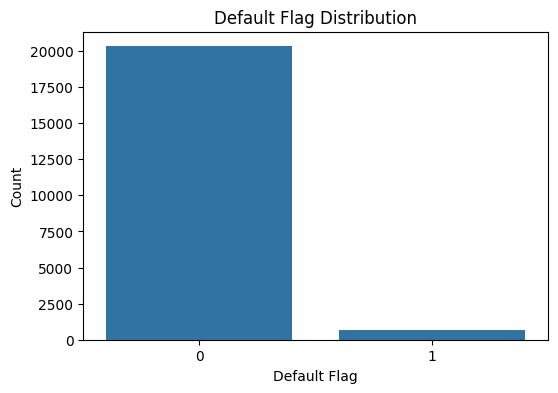

In [8]:
# Target variable distribution
print(df["default_flag"].value_counts())
print("\nPercentage Distribution:\n")
print( df["default_flag"] .value_counts(normalize=True) * 100 )

# Target distribution visualization
plt.figure(figsize=(6,4))

sns.countplot(
    x="default_flag",
    data=df
)

plt.title("Default Flag Distribution")

plt.xlabel("Default Flag")
plt.ylabel("Count")

plt.show()

Observation:
* The target variable exhibits noticeable class imbalance, with non-default cases (0) significantly outnumbering default cases (1)
* Approximately 3.25% of the records belong to the default class, while nearly 96.75% belong to the non-default class.
* This distribution is consistent with realistic financial risk environments where default events are comparatively rare.


## 2. Engineered Features and Risk Indicators



Several variables in the dataset are engineered features derived from academic, financial, and behavioral information. These indicators are designed to capture latent risk patterns that may not be directly observable from raw variables alone. The following section summarizes the purpose, mathematical formulation, and interpretation of the key engineered features used throughout the analysis.


### ECS – Enrollment Continuity Score
#### Full Form
Enrollment Continuity Score
#### Formula
$$\text{ECS} = \frac{\text{semesters enrolled}}{\text{expected total semesters}}$$
#### Purpose
Measures the degree to which a student is progressing through their educational program without interruption.
#### Interpretation

* Higher ECS → Stronger enrollment continuity and academic progression.
* Lower ECS → Potential academic disruption or delayed progression.

#### Why Included
Enrollment continuity is a useful indicator of student stability and future completion likelihood.

---

### GDI – GPA Direction Index
#### Full Form
GPA Direction Index
#### Formula
$$\text{GDI} = \{\text{improving}: +1, \text{stable}: 0, \text{declining}: -1\}$$
#### Purpose
Converts GPA trends into a numerical indicator suitable for quantitative analysis and machine learning.
#### Interpretation

* +1 → Academic performance improving.
* 0 → Academic performance stable.
* -1 → Academic performance declining.

#### Why Included
Changes in academic performance may serve as an early signal of educational or financial stress.

---

### ACR – Aid Coverage Ratio
#### Full Form
Aid Coverage Ratio
#### Formula
$$\text{ACR} = \frac{\text{aid amount} + (\text{monthly inflow mean} \times 4)}{\text{estimated tuition} + \text{estimated living cost}}$$
#### Purpose
Measures the extent to which educational expenses can be covered through available financial resources.
#### Interpretation

* High ACR → Educational expenses are largely covered.
* Low ACR → Greater financial burden on the student.

#### Why Included
Students with lower aid coverage may experience increased financial pressure and repayment risk.

---

### CFRI – Cash Flow Resilience Index
#### Full Form
Cash Flow Resilience Index
#### Formula
$$\text{CFRI} = 1 - \text{cash flow cv}$$
where:
$$\text{cash flow cv} = \text{coefficient of variation of monthly cash flow}$$
#### Purpose
Measures the stability and predictability of a student's cash inflows.
#### Interpretation

* High CFRI → Stable and reliable income stream.
* Low CFRI → Volatile and unpredictable income stream.

#### Why Included
Income volatility is a known contributor to financial stress and repayment difficulties.

---

### OPR – Obligation Punctuality Rate
#### Full Form
Obligation Punctuality Rate
#### Formula
$$\text{OPR} = \text{bill payment rate}$$
#### Purpose
Measures how consistently a student fulfills recurring financial obligations on time.
#### Interpretation

* High OPR → Strong payment discipline.
* Low OPR → Weak payment behavior.

#### Why Included
Past payment behavior is often predictive of future repayment performance.

---

### TGB – Time-to-Graduation Buffer
#### Full Form
Time-to-Graduation Buffer
#### Formula
$$\text{TGB} = \text{Normalize}\left(\frac{\ln(1 + \text{remaining semesters})}{\ln(1 + \text{synthetic debt load})}\right)$$
#### Purpose
Measures a student's ability to absorb academic delays while managing existing financial obligations.
#### Interpretation

* High TGB → Greater flexibility and resilience against academic or financial disruptions.
* Low TGB → Increased vulnerability to educational and financial stress.

#### Why Included
The balance between remaining study duration and existing debt provides additional insight into long-term risk exposure.

----

### Summary
The engineered features described above transform raw academic, financial, and behavioral variables into interpretable risk indicators. Together, they provide additional context regarding enrollment continuity, academic trajectory, financial adequacy, income stability, payment discipline, and graduation resilience, thereby supporting downstream exploratory analysis, risk assessment, and predictive modeling.



## 3. Univariate Analysis

Univariate analysis focuses on understanding the behavior and distribution of individual features independently before analyzing inter-feature relationships. This stage helps identify:

* distribution patterns
* concentration of values
* skewness
* outliers
* dominant categories

### Numerical Features

#### Temporal / Ordinal Numerical Features


Temporal or ordinal numerical features represent ordered progression, sequential stages, or lifecycle-based behavior patterns rather than purely measurable continuous quantities.

* The identified temporal/ordinal features may later support semester-based trend analysis and behavioral progression studies during temporal EDA stages.

* Such features are separated to avoid misleading distribution interpretation alongside standard continuous variables.

In [9]:
# Manually identify temporal/sequential features

temporal_cols = [ "semesters_enrolled", "remaining_semesters" ]

 # Display temporal features
print("Temporal / Ordinal Features:\n")
print(temporal_cols)

Temporal / Ordinal Features:

['semesters_enrolled', 'remaining_semesters']


#### Discrete Numerical Features

Discrete numerical features contain limit count-based or integer-valued observations. these variables generally represent behavioral frequency patterns,count-oriented attributes.
They are analyed seperately because their is different from continous measurable financial quantities.

In [10]:
#Remaining Numerical Features
remaining_num_cols=[col for col in num_cols   #Numerical Features apart from temporal features
                    if col not in temporal_cols]

#Discrete Numerical Features
discrete_cols=[ col for col in remaining_num_cols
               if df[col].nunique()<15] #Having more than 15 different numbers

print("Discrete Numerical Features:\n")
print(discrete_cols)

Discrete Numerical Features:

['academic_year', 'expected_total_semesters', 'aid_disbursement_flag', 'campus_employment', 'gig_income_flag', 'subscription_count', 'prior_delinquency', 'application_week', 'academic_calendar_flag', 'gdi']


Frequency/Distribution Analysis

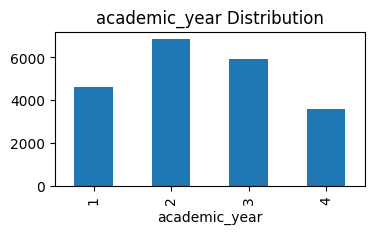

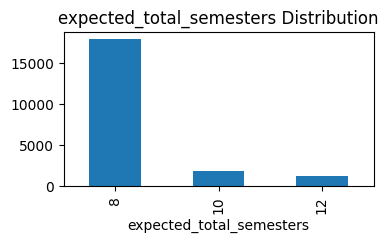

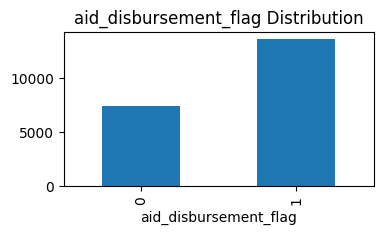

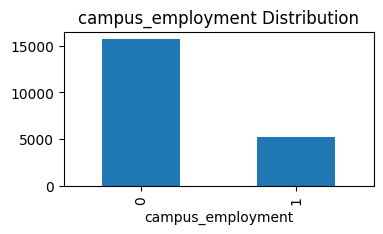

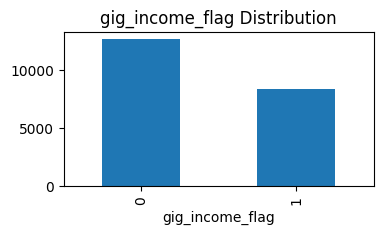

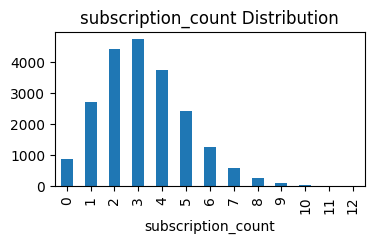

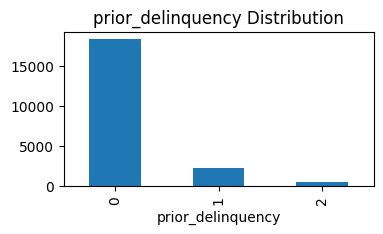

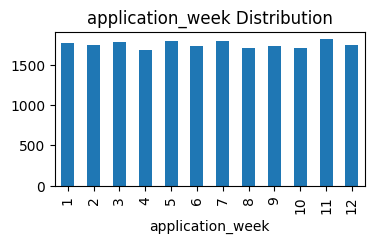

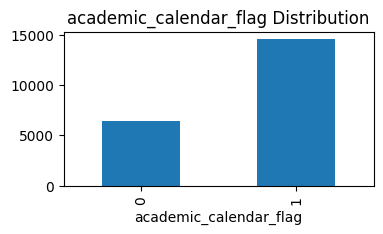

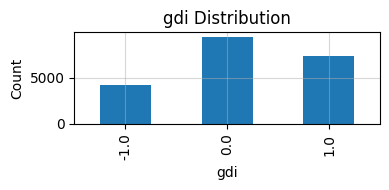

In [11]:
#Distribution Analysis

for col in discrete_cols:     #Iterating through discrete columns

  plt.figure(figsize=(4,2))   #Figure size

# Making a bar plot for each feature while counting number of unique values and sort them
  df[col].value_counts().sort_index().plot(kind="bar",title=f"{col} Distribution")


#Naming x and y labels
plt.xlabel(col)
plt.ylabel("Count")
plt.grid(alpha=0.5)
plt.tight_layout()

plt.show() #Show graph



Observation:
* **academic_year:** The student population is predominantly concentrated in their sophomore(2) and junior(3) years followed by freshmen(1) and seniors(4).
  * The lower application volume in Year 1 likely reflects initial aid sufficiency or restricted access to credit, while the drop in Year 4 suggests shifting financial behaviors nearing graduation.
* **expected_total_semsters:** The vast majority aligns with a 8-semester(4-year) completion track.However,long tail extending to 10 and 12 semesters successfully captures simulated academic friction such as part-time transitions,class reptitions,etc.
  * This subset identifies students who prolong their enrollment to maintain financial aid until employment, directly increasing their risk of exceeding their maximum graduation timeline.
* **aid_disbursement_flag:** A significant majority of the records flag positive(1) for recieving Financial Aid.
This confirms the underlying synthetic population relies heavily on institutional funding rather than purely independent income or parental wealth.
* **campus_employment:** Only a minority of the population (~25-30%) holds stable, on-campus employment. This highlights that the bulk of the portfolio lacks guaranteed, predictable institutional income, making cash-flow modeling critical.
* **gig_income_flag:** A notable segment of the population relies on gig-economy work. While this provides necessary liquidity, it introduces structural income volatility compared to those with stable campus jobs.
* **subscription_count:** The distribution exhibits a strong right skew. The volume peaks predictably at 2-3 recurring subscriptions, establishing a baseline for modeling consistent monthly cash outflows.
* **prior_delinquency:** This feature exhibits severe class imbalance, peaking massively at 0. As expected for a thin-file demographic, the vast majority of applicants have clean histories. The rare occurrences of 1 or 2 represent risk signals that are critical for downside risk segmentation and application blocking.
* **application_week:** The distribution remains roughly uniform across the tracked weeks. This provides a stable baseline of application volume, allowing the model to clearly identify anomalous surges when overlaid with seasonal stress flags.
* **academic_calendar_flag:** The data is heavily skewed toward the premium class (1). This confirms that credit demand is structurally driven by high-stress, high-need windows such as FAFSA delays, semester-end depletion, or summer gaps rather than stable mid-semester periods (0).
* **gdi:**(GPA DIRECTION INDEX) The distribution confirms that most students maintain stable (0) or improving (1) academic trajectories. The minority class (-1, declining) successfully isolates the higher-risk segment, utilizing directional academic momentum as an indicator for behavioral discipline and future financial stability.

#### Continous Numerical Features



Continuous numerical features represent measurable financial or behavioral quantities distributed across broader numerical ranges.


In [12]:
#Continous Numerical features
continuous_cols = [col for col in remaining_num_cols
    if col not in discrete_cols #Features apart from discrete which are numerical
]

print("\nContinuous Numerical Features:\n")
print(continuous_cols)


Continuous Numerical Features:

['synthetic_age', 'credit_hours_current', 'monthly_inflow_mean', 'cash_flow_cv', 'aid_amount', 'estimated_tuition', 'estimated_living_cost', 'synthetic_debt_load', 'bill_payment_rate', 'ecs', 'acr', 'cfri', 'opr', 'tgb', 'spra', 'sei']


##### Histogram Analysis

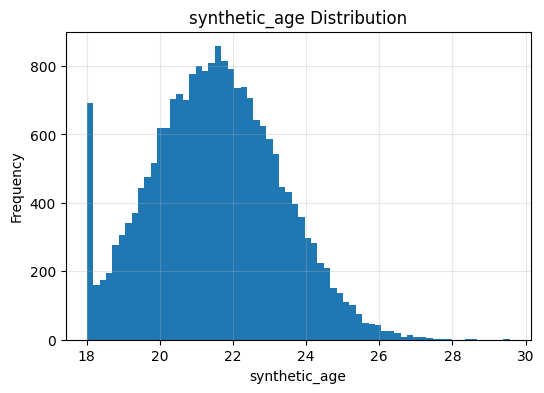

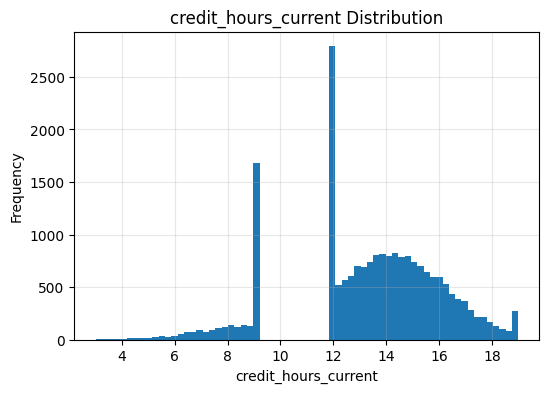

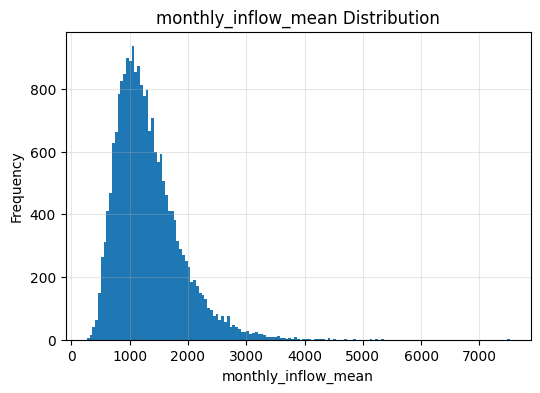

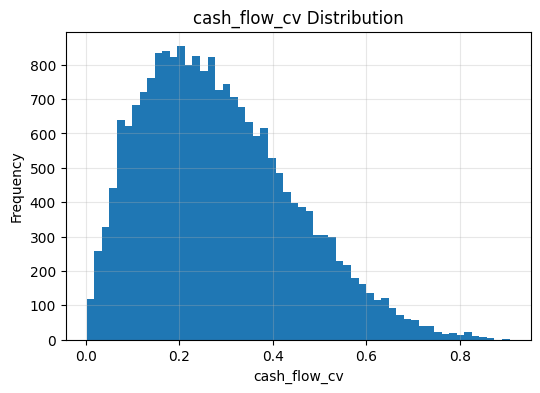

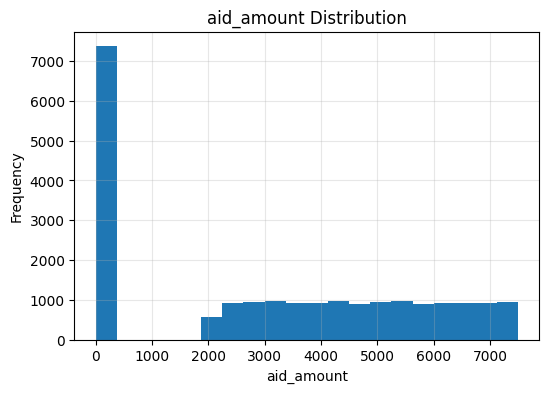

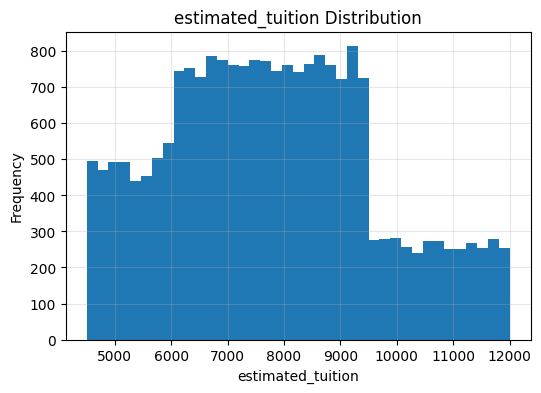

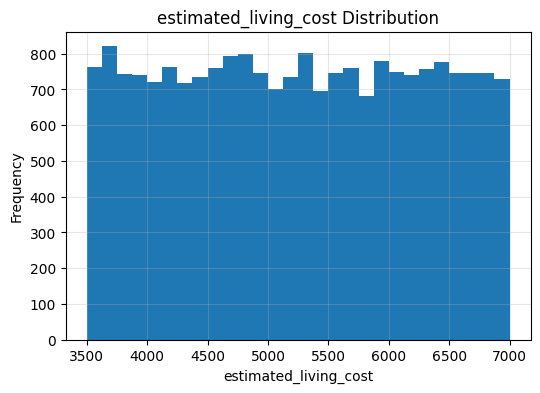

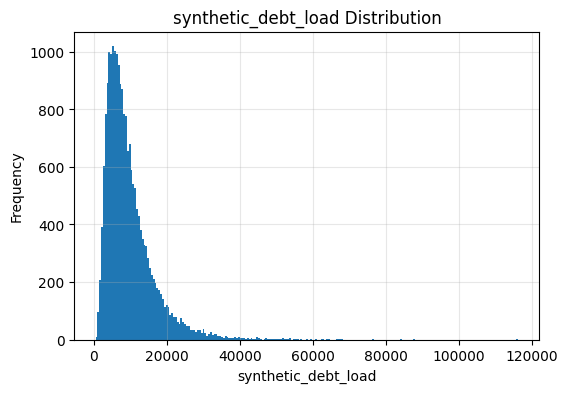

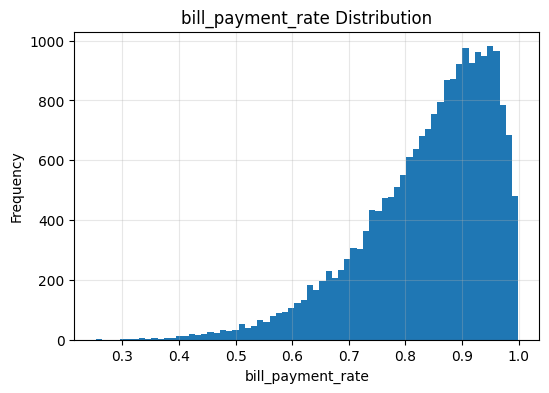

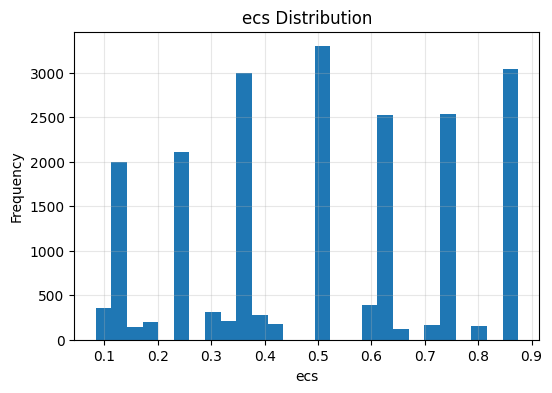

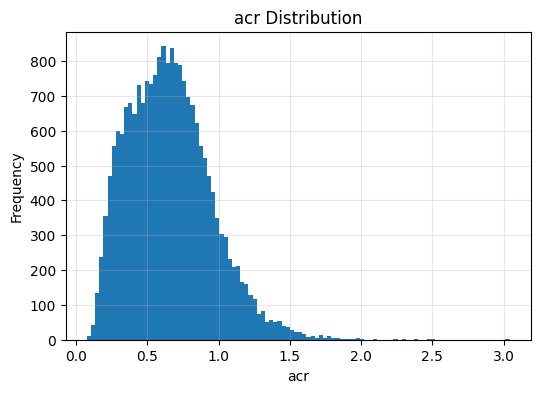

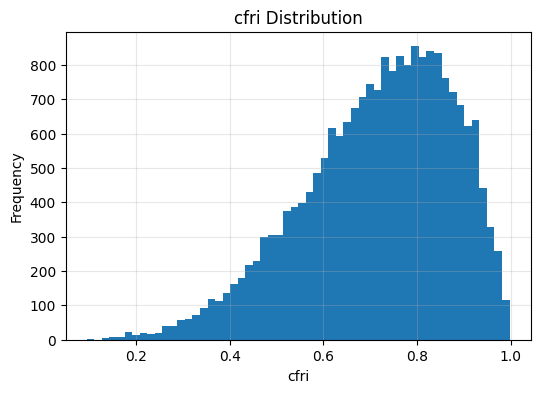

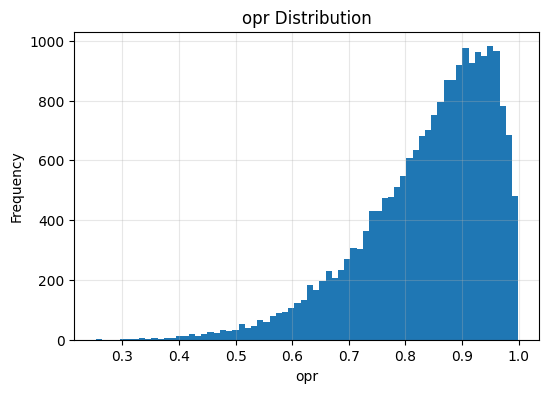

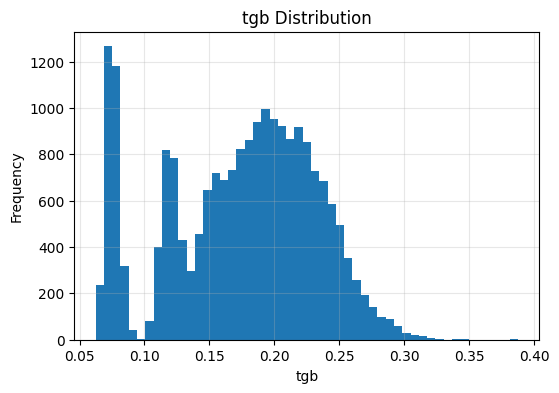

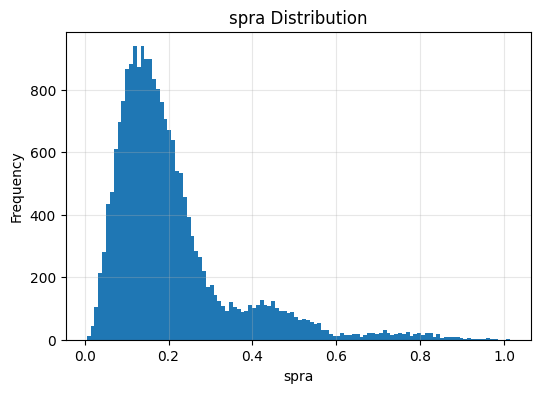

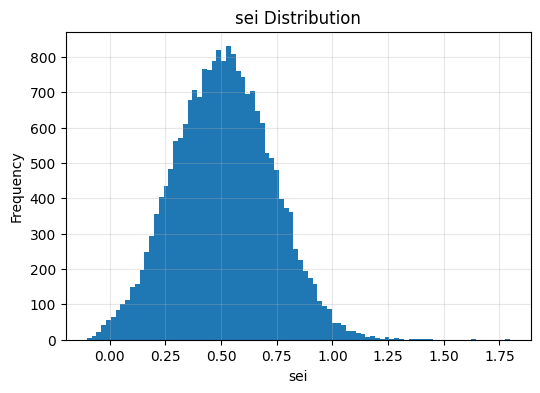

In [13]:
#Histograms for Continous Numerical Features

for col in continuous_cols:

    plt.figure(figsize=(6,4))

    plt.hist(df[col],bins='auto')

    plt.title(f"{col} Distribution")

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.grid(alpha=0.3)

    plt.show()

Observations:
* **synthetic_age:** The distribution is a right-skewed curve with a peak at exactly 18 years old,indicating the strict age-eligibility threshold for credit applications.
  * The core density sits within the 20–24 range, accurately representing the traditional undergraduate demographic.
  * The long right tail captures a smaller population of mature or graduate students.

* **credit_hours_current:** This multi-modal distribution is due to institutional policy and not natural variance and a broader curve between 13-18 capturing full-time academics.
  * The massive spikes a 9 and 12 credits represent strict academic cutoffs for "Full-Time" and "Part-Time" status respectively.
  * This confirms that students adjust their schedules to financial aid and enrollment requirements.

* **monthly_inflow_mean:** The right-skewed distribution peaks around 1000 with vast majority of the students living on a monthly inflow between 500-3000. This displays the liquidity constraints of dataset and propoerly displays the lower-income reality of students before graduation.


* **cash_flow_cv:**
(Coefficient of Variation)
This distribution shows a broad spectrum of income volatility.
  * While a solid majority of the portfolio remains below the 0.5 threshold indicating relatively predictable cash flows.
  * A substantial and distinct minority sits in the long right tail (CV > 0.5) displaying the high-risk segment relying heavily on irregular, volatile liquidity, such as gig-economy work or unpredictable external support.

* **aid_amount:** The distribution reveals a bimodal structure.
  * A massive peak at zero shows that 7000+ students are not receiving federal aid.
  * The remaining students that do recieve funding the distribution is uniform across the 2000-7500 range indicating aid packages are granted evenly across loan limit tiers.

* **estimated_tuition:** Instead of a smooth curve the data forms three distinct,block-like tiers. These might be representing underlying institutional pricing structures:
  * Low Tier (Community Colleges): 4500-6000
  * Mid tier (State-Public Universities): 6000-9500
  * Upper tier (Private):9500+

* **estimated_living_cost:** This feature displays a flat,uniform distribution between 3000-7000.Living and housing costs are distributed evenly across the population, without clustering giving a stable denominator for downstream liquidity ratios.

* **synthetic_debt_load:** The distribution is heavily right-skewed, the bulk of the density is at lower debt levels,this represents early-stage borrowers or students with aid coverage. The long,thin right tail isolates senior year and graduate students whose debt compounded over multiple years.

* **bill_payment_rate:** Strongly left-skewed, this distribution confirms that the majority of thin-file students successfully manage basic recurring obligations. By establishing a high baseline of financial discipline, the trailing left tail becomes a highly sensitive behavioral proxy for identifying early derogatory risk.

* **ecs:**(Enrolllment Continuity Score) The histogram reveals a discrete, fractional structure rather than a continuous spread. The isolated pillars reflect exact mathematical ratios of semesters enrolled versus expected (e.g., 0.5 for 4/8 semesters, 0.75 for 6/8 semesters).These indicate academic friction like gap semesters or dropout/re-enrollment events.

* **acr:**(Aid Coverage Ratio)
  The distribution is right-skewed, with the majority of the density falling near or below the critical 1.0 threshold.This shows that estimated tution and living costs generally are more than combined aid and income for most of the students making it valid to get loans for survival.

* **cfri:**(Cash flow Regularity Index) It is the mathematical inverse of **cash_flow_cv** this left-skewed distribution demonstrates most students maintain a stable income (CFRI>0.6).The left tail effectively isolates high-risk students struggling with irregular cash flow.

* **opr:**(Obligation Punctuality Rate) This is directly from **bill_payment_rate**, the heavily left-skewed distribution confirms basic financial discipline across the dataset.As these applicants lack credit history,for the minority in the curve this serves as a signal for any underlying difficulty that might happen during repayment.

* **tgb:**(Time to Graduation Buffer) The distribution has a complex shape which can be related with debt accumulation and academic progress.The sharp peak at the start can be due to early-stage students getting their intial debt.The curve at centre is natural lifecycle where debt is compounded and as one is approaching graduation it shrinks.

* **spra:**(Semester Phase Risk Adjustment) This right-skewed distribution is peak at around 0.15,this indicates most of the loans are during standard 'mid semester' phase.The long right tail indicates for applications during high stress windows such as semester-end transition or summer gaps.

* **sei:**(Stress Event Indicator) The distribution is normal centred at 0.5 that an average student operates around this baseline of financial friction.The extreme right-tail outliers(>1.5) capture "Compound Crisis Events" where a student has combined aid loss and part-time transition etc. This makes sei into a routing feature isolating high severity accounts for intervention.



##### Boxplot Analysis

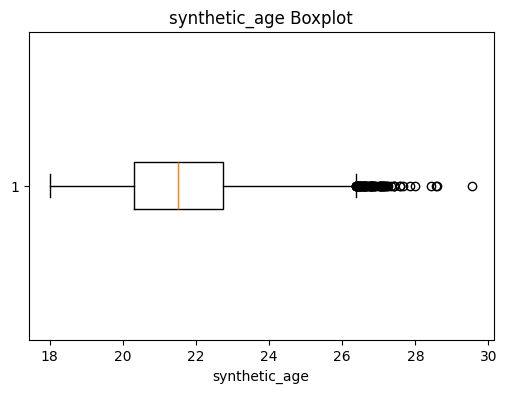

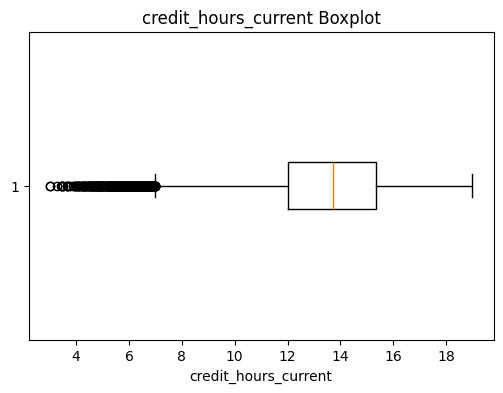

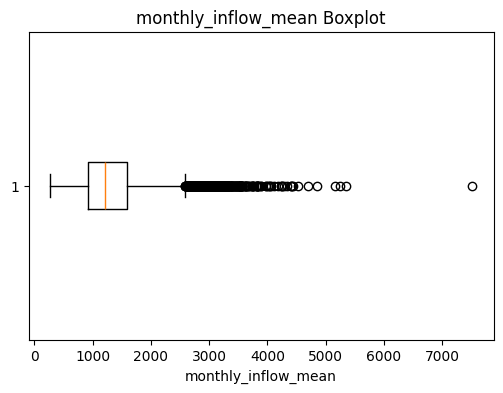

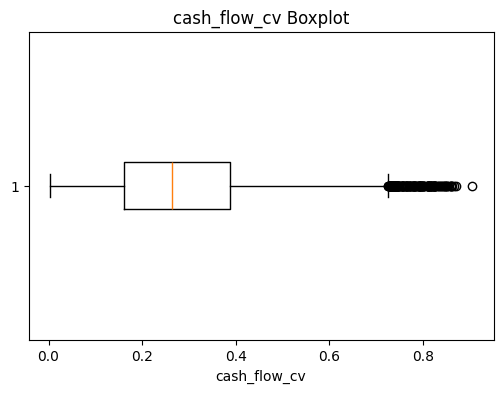

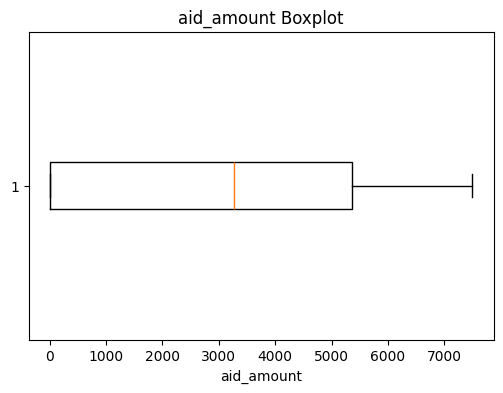

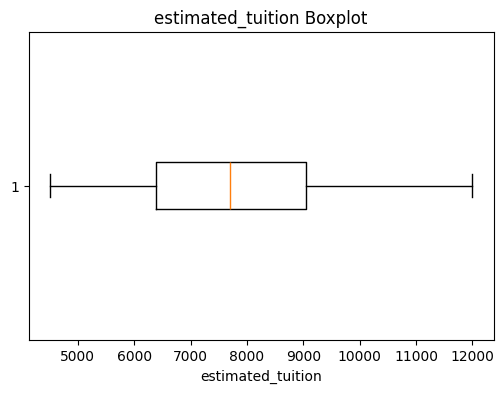

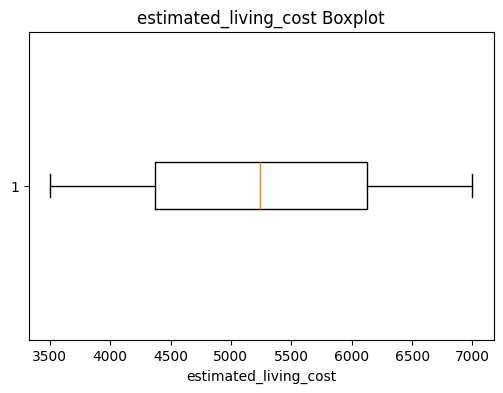

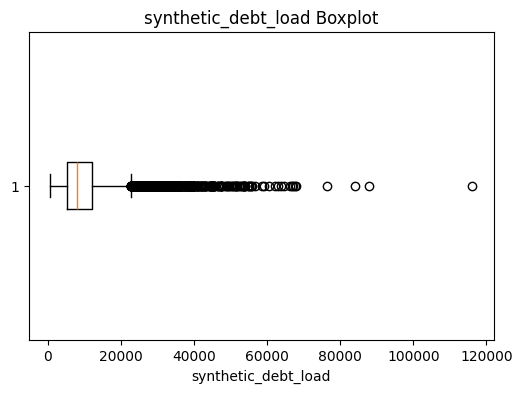

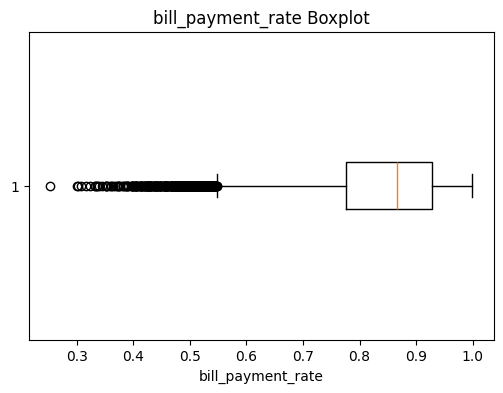

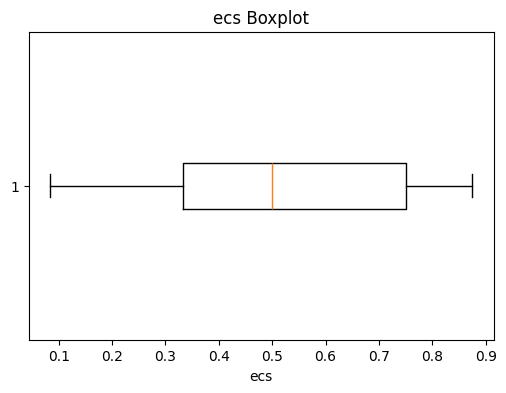

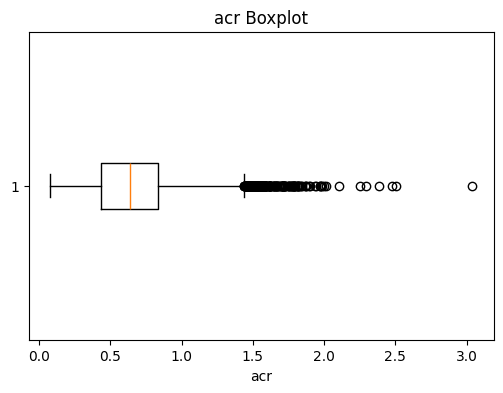

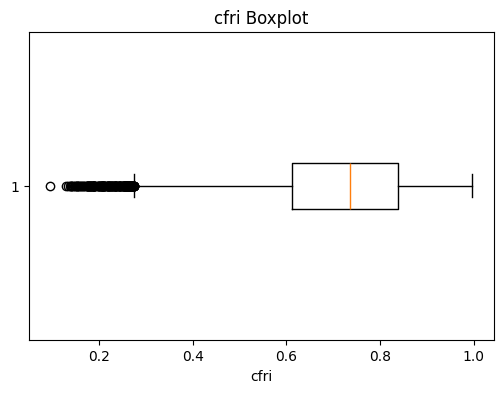

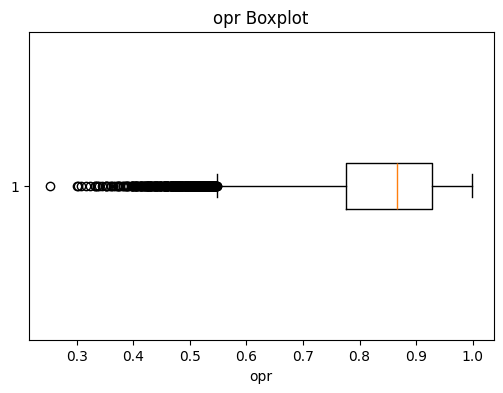

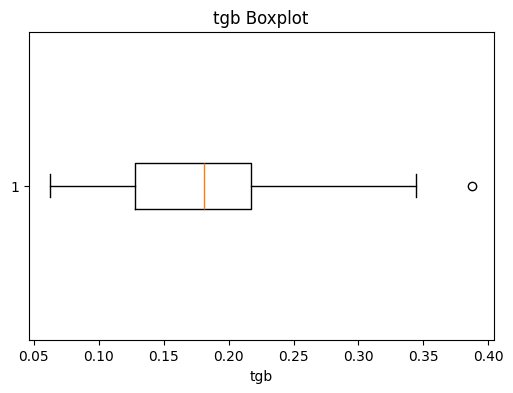

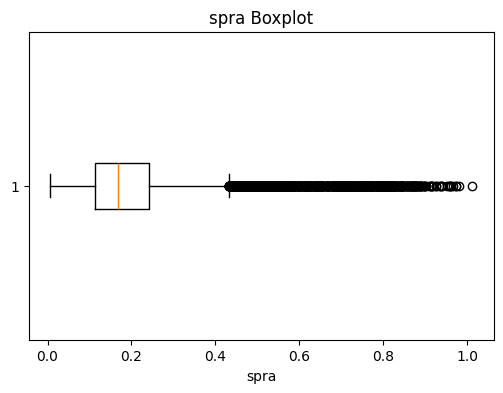

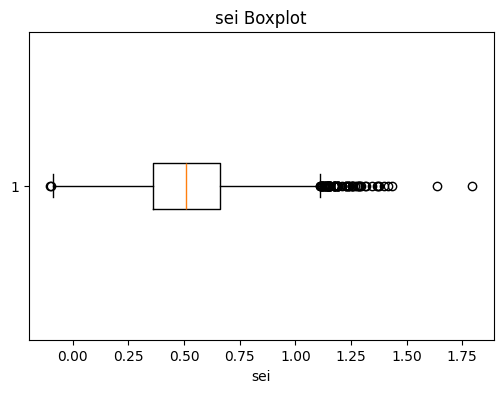

In [14]:
for col in continuous_cols:

    plt.figure(figsize=(6,4))

    plt.boxplot(
        df[col],
        vert=False
    )

    plt.title(f"{col} Boxplot")

    plt.xlabel(col)

    plt.show()

Observations:
* **synthetic_age:** The whiskers have are within the typical undergraduate population.The right-side outliers form a dense,heavy tail upto 28 this represents legitimate graduate students.The single outlier near 29 is within realistic bounds and does not required to be removed.

* **credit_hours_current:** While the IQR captures the standard full-time load, the critical insights lie in the left-tail outliers.Records below the 6 credit whisker represents "less-than-half-time" or studnets who are in academic withdrawal,they can be highly predictive organic outliers signaling an immediate drop in academic persistence and future income generation.

* **monthly_inflow_mean:** The plot exhibits a  organic heavy tail extending beyond the upper whisker, capturing the subset of students with high parental support or high-yield employment. However, the extreme, isolated outliers exceeding $7,000 must be flagged for investigation to determine if they represent high-earning professionals returning to school or generation errors.

* **cash_flow_cv:** (Coefficient of Variation)
The upper bound outliers represent a valid, high-volatility students heavily reliant on unpredictable income such as gig jobs. Outliers approaching the 1.0 limit are critical risk proxies, can be used to immediately disqualify a loan  due to cash flow instability.

* **aid_amount:** The box plot reveals zero upper outliers, confirming the synthetic generator successfully follows the strict institutional and federal funding limits. The lower whisker and IQR are heavily compressed due to the large zero-aid population previously identified in histogram analysis.

* **estimated_tution:** Strictly bounded boxes with zero outliers.

* **estimated_living_cost:** Strictly bounded boxes with zero outliers.

* **synthetic_debt_load:** The dense cluster of upper outliers up to 60000 is an expected organic heavy tail representing 8th- to 12th-semester seniors with compounding debt. However, the sparse, extreme isolated outliers (>70,000)  far beyond the cluster are likely data generation errors. These extreme values will distort distance-based or gradient-boosted ML models and should be clipped (e.g., capped at the 99th percentile) during preprocessing.

* **bill_payment_rate:** The left-skewed heavy tail represents standard variation with minor low payment rate studnets.For the deep outliers at 0 this acts a primary risk signal for Thin-File students.

* **ecs:** (Enrollment Continuity Score)
The plot shows strict bounding with zero outliers.

* **acr** (Aid Coverage Ratio)
This plot reveals a critical insight: the upper outliers (> 2.0) are highly suspicious. An ACR of 2.0+ implies the student has twice the required cash to survive the semester. If these records are applying for credit, it strongly signals something suspcious like borrowing to route money elsewhere/invest or a logical flaw in the synthetic generation. These records must be specifically isolated and audited.

* **cfri:** (Cash Flow Regularity Index)
Mirroring the cash_flow_cv, the extreme lower-bound outliers near 0.0 effectively flag the students who are  experiencing absolute income unpredictability.

* **opr:** (Obligation Punctuality Rate)
The trailing left-tail outliers form a distinct, high-risk behavioral segment. The natural separation of outliers below the 0.4 mark makes this feature a prime candidate for feature division making these continuous outlier clusters into hard categorical risk tiers for the final scorecard.

* **tgb:** (Time-to-Graduation Buffer)
The upper bound outliers represent students with an extremely high runway-to-debt ratio such as freshmen with zero debt.

* **spra:** (Semester Phase Risk Adjustment)
The right-heavy tail captures the elevated risk penalties applied during non-standard application windows. The absolute outliers hitting the 1.0 limit represent maximum penalties, successfully flagging high-stress scenarios like unfunded summer gaps.

* **sei:** sei (Stress Event Indicator)
While the IQR covers standard financial friction, the two distinct, extreme outliers above 1.5 confirm the presence of "Compound Crisis Events." These outliers mathematically prove that some students are experiencing multiple, simultaneous structural shocks like dropping enrollment while losing aid, validating sei as an operational trigger for immediate manual intervention.

### Categorical Features

Categorical features represent grouped or label-based information describing academic, behavioral, or demographic categories.


In [15]:

# Categorical Features


print("Categorical Features:\n")

for col in cat_cols:

    print(col)

Categorical Features:

enrollment_type
major_category
gpa_direction
savings_behavior
semester_phase
dataset_split


#### Cardinality Analysis

In [16]:

# Categorical Feature Cardinality


cardinality_df = pd.DataFrame({   #making a dataframe with the columns

    "Feature": cat_cols,          #Feature name

    "Unique Categories": [        #No. of unique categories

        df[col].nunique()         #Counting the no. of distinct values

        for col in cat_cols
    ]
})

cardinality_df = cardinality_df.sort_values(  #sort the rows in df
    by="Unique Categories",       #In descending order by the value in Unique Categories
    ascending=False
)

print(cardinality_df)

            Feature  Unique Categories
1    major_category                  4
2     gpa_direction                  3
4    semester_phase                  3
3  savings_behavior                  3
0   enrollment_type                  2
5     dataset_split                  1


Observations:
* The dataset is exceptionally clean, with all predictive categorical features possessing very low cardinality (strictly between 2 and 4 unique categories).
* With the maximum cardinality capped at just 4 distinct values (in major_category), structural rare categories are highly unlikely to disrupt the model. Any low-frequency values observed will stem from natural simulated class imbalance rather than extreme data fragmentation.
* dataset_split is to be dropped


In [17]:
cat_cols = [col for col in cat_cols if col != 'dataset_split']
# Drop the column
df = df.drop(columns=['dataset_split'])

#### Category Distribution Analysis

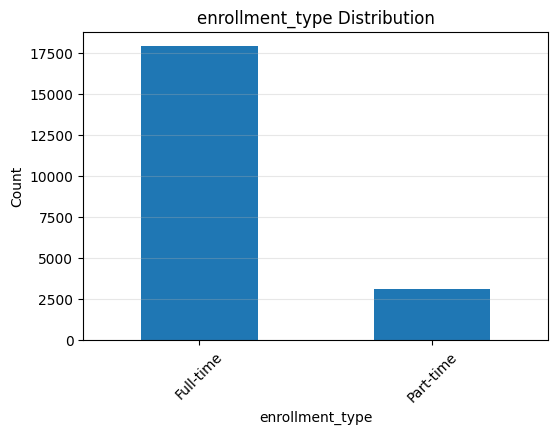

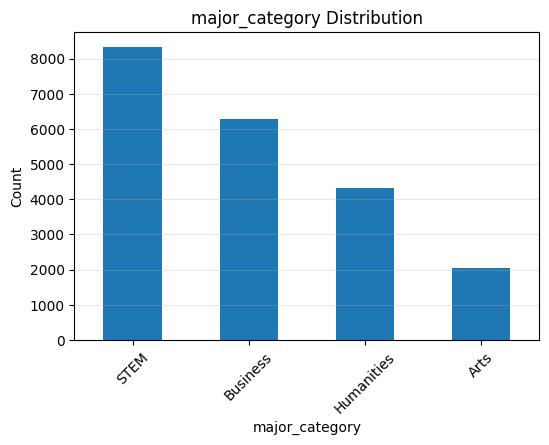

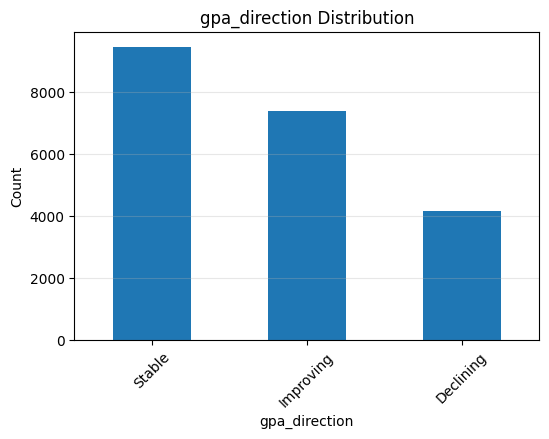

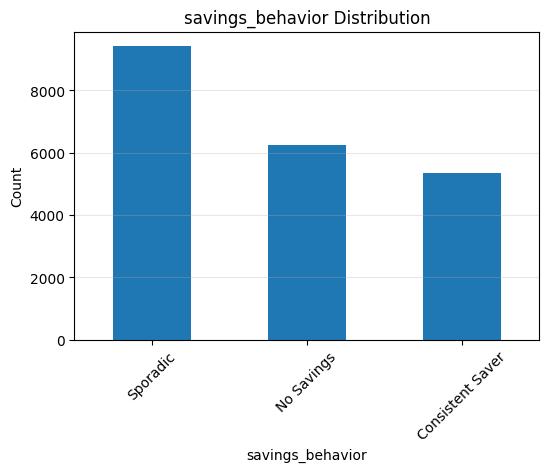

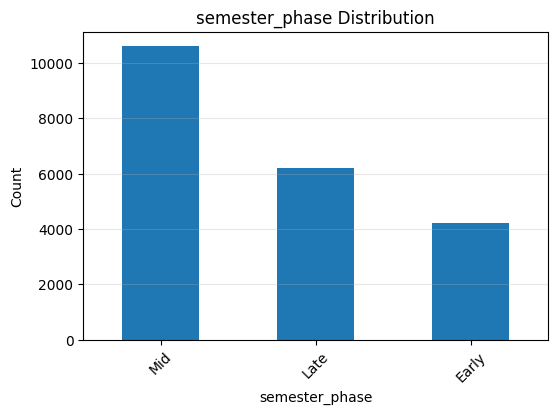

In [18]:

# Category Distributions


for col in cat_cols:

    plt.figure(figsize=(6,4))

    df[col].value_counts().plot(    #Bar plot
        kind="bar"
    )

    plt.title(f"{col} Distribution")  #Title of plot

    plt.xlabel(col)
    plt.ylabel("Count")

    plt.xticks(rotation=45)

    plt.grid(axis="y", alpha=0.3)

    plt.show()

Observations:
* **enrollment_type:** The  majority of students maintains full-time status. The minority part-time segment serves as a critical  proxy in the model: it typically indicates either a positive shift toward full-time employment (increasing current liquidity) or a negative signal of academic scaling-back (reducing future graduation probability).

* **major_category:** STEM disciplines dominate the dataset, comprising approximately half of the dataset, sequentially followed by Business, Humanities, and Arts.

* **gpa_direction:** The portfolio exhibits strong academic health, with the majority of students displaying stable or improving trajectories. This is a robust leading indicator for the Enrollment Continuity Score (ecs), as stable grades directly correlate with a higher probability of graduation and subsequent repayment capacity.

* **savings_behavior:** While the baseline behavior across the dataset is sporadic, the segment demonstrating consistent, regular saving habits is highly predictive. In the absence of traditional FICO scores, this structural financial discipline acts as a powerful proxy for repayment reliability, and major protective factor against default.

* **semester_phase:** Application volume accurately mirrors the operational academic calendar rather than pure risk. The Mid phase captures the highest absolute volume due to its duration and steady-state borrowing needs. The Late phase follows, driven by end-of-term liquidity crunches, while the Early phase sees the lowest volume as students are engaged with initial enrollment and aid disbursement.



#### Category Proportions

In [19]:

# Category Percentages


for col in cat_cols:

    print("\n" + "="*50)
    print(col)
    print("="*50)

    print(

        round(

            df[col]
            .value_counts(normalize=True) * 100,2   #Value rounded to 2 decimal places
            )
        )


enrollment_type
enrollment_type
Full-time    85.21
Part-time    14.79
Name: proportion, dtype: float64

major_category
major_category
STEM          39.71
Business      29.98
Humanities    20.52
Arts           9.79
Name: proportion, dtype: float64

gpa_direction
gpa_direction
Stable       45.01
Improving    35.13
Declining    19.86
Name: proportion, dtype: float64

savings_behavior
savings_behavior
Sporadic            44.82
No Savings          29.74
Consistent Saver    25.43
Name: proportion, dtype: float64

semester_phase
semester_phase
Mid      50.47
Late     29.50
Early    20.03
Name: proportion, dtype: float64


Observations:
Here is the exact, ready-to-paste summary for your notebook:

**Overall Categorical Proportion Summary**
Analysis of the categorical percentages confirms that every category maintains a healthy, statistically significant proportion of the dataset. Because no category is severely underrepresented, there is no risk of minority-class model bias, confirming that no manual data interventions or rebalancing techniques are required prior to model training.

## 4.Target-Based Analysis (Feature vs Target)

The objective of this section is to transition from understanding the standalone shape of the data (Univariate) to evaluating its predictive power. We will systematically test our independent variables against the dependent target variable (`default_flag`).

Rather than generating exhaustive plots for every feature, this analysis focuses on hypothesis testing: isolating the specific behavioral, academic, and financial features that demonstrate a statistically significant or visually distinct pattern of altering default risk.

### Categorical Features vs Target

To accurately assess categorical risk, looking strictly at default rates is insufficient without volume context. Therefore, we utilize **Count Plots (`hue='default_flag'`)** to visualize both category volume and target class separation simultaneously. This visual analysis is strictly supported by **Chi-Square ($x^2$)** tests of independence to validate if the observed differences in default rates are statistically significant (p < 0.05).

Prior to statistical validation, the following behavioral and demographic assumptions were established based on univariate observations:
* **GPA Direction:** Declining grades signal academic distress and will directly correlate with a higher probability of default.
* **Savings Behavior:** Consistent savers possess a structural financial shield, heavily reducing default risk compared to those with zero savings.
* **Major Category:** STEM and Business degrees will demonstrate significantly lower risk than Arts/Humanities due to higher anticipated post-graduate earning potential.
* **Enrollment Type:** Part-time status will reflect higher risk due to delayed graduation timelines or academic scaling-back.
* **Semester Phase:** Late-phase applications will carry distinctly higher risk due to end-of-term liquidity crunches compared to the steady-state Mid-phase.

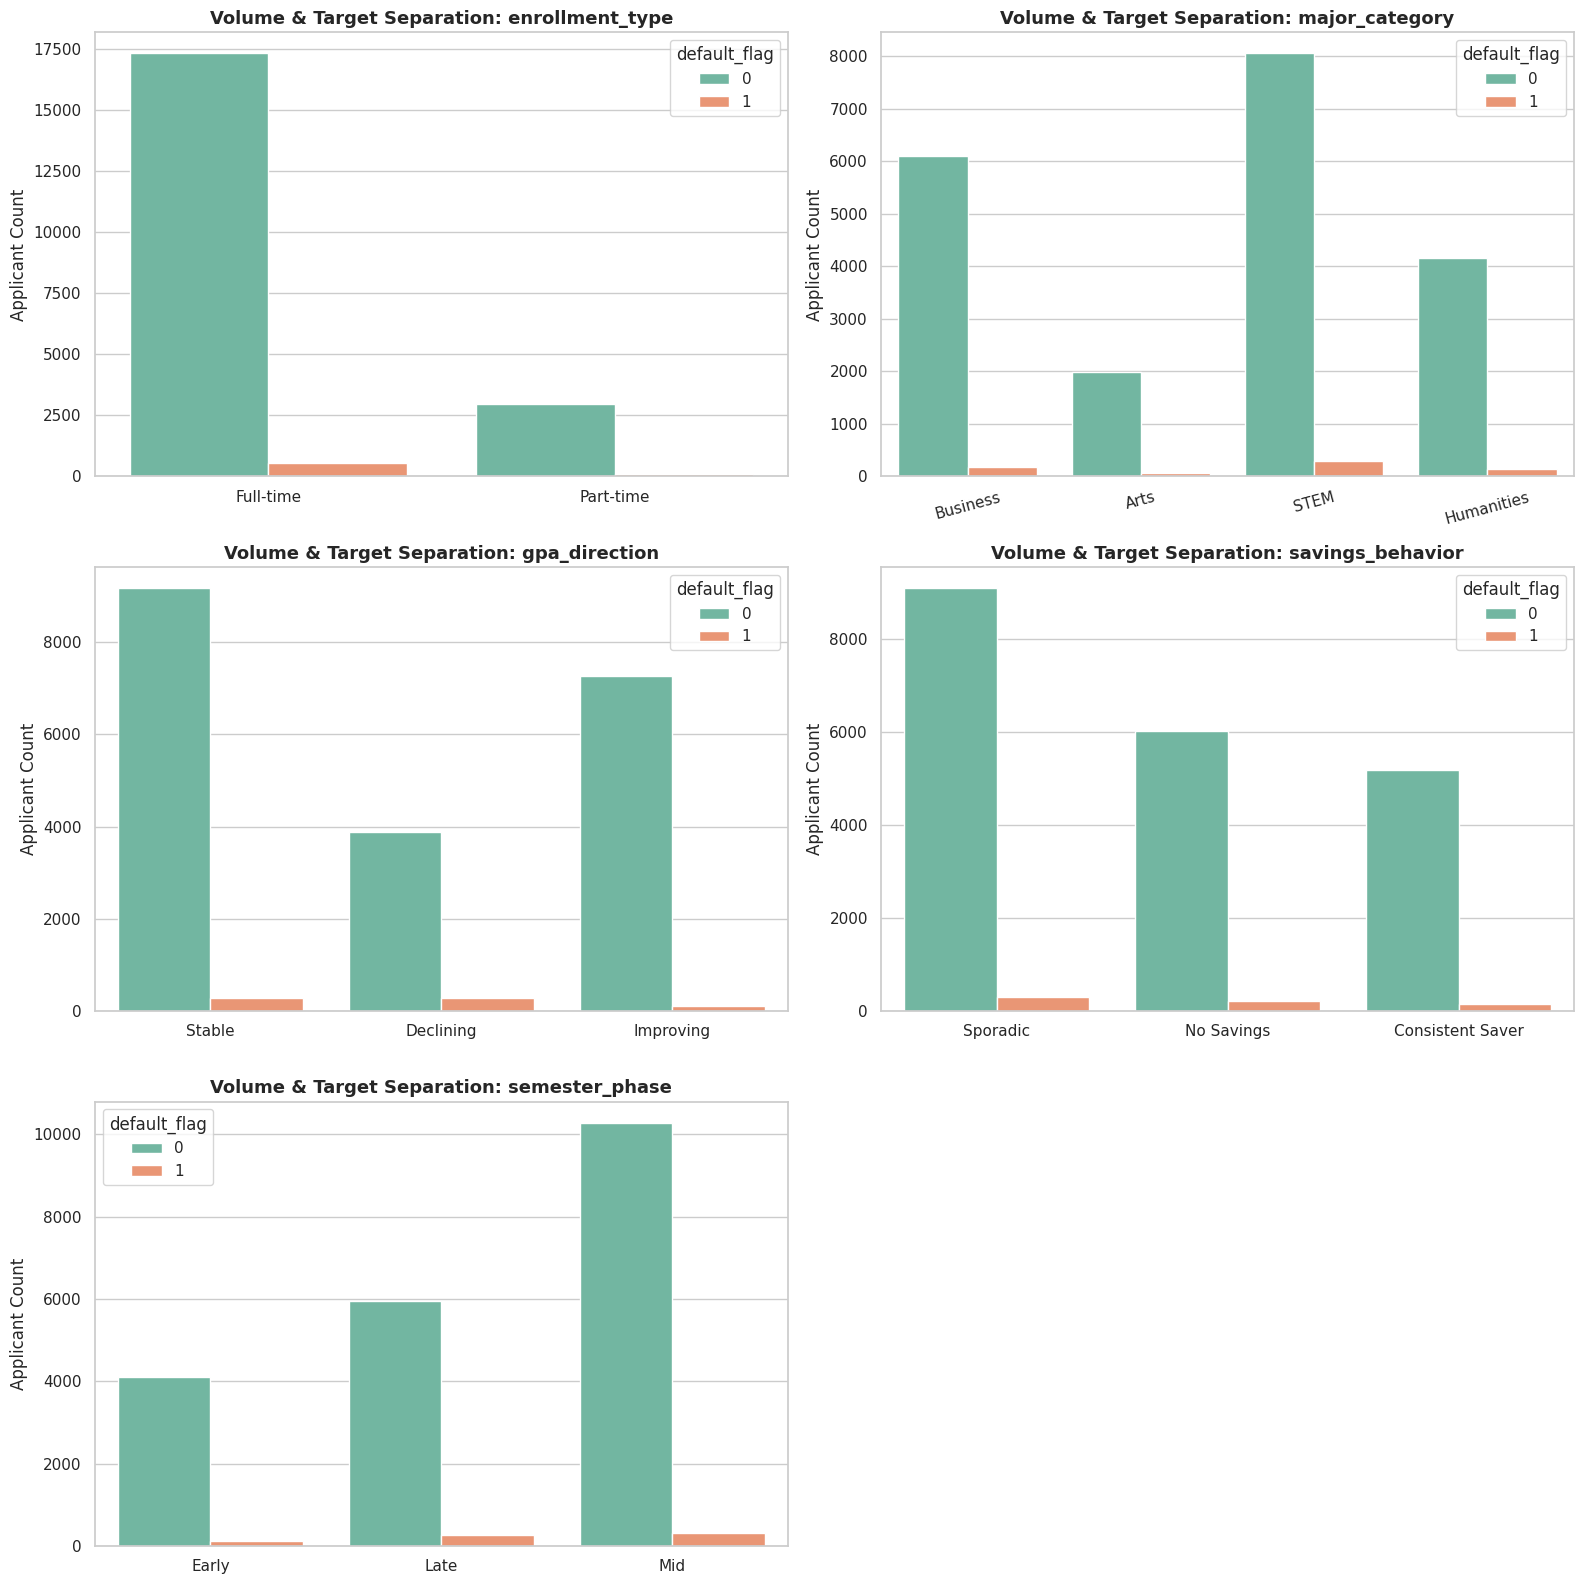

--- Chi-Square Validation for Categorical Features ---
Feature: enrollment_type    | P-Value: 0.0311 | SIGNIFICANT  (Reject Null)
Feature: major_category     | P-Value: 0.2737 | NOT SIGNIFICANT  (Fail to Reject)
Feature: gpa_direction      | P-Value: 0.0000 | SIGNIFICANT  (Reject Null)
Feature: savings_behavior   | P-Value: 0.3999 | NOT SIGNIFICANT  (Fail to Reject)
Feature: semester_phase     | P-Value: 0.0000 | SIGNIFICANT  (Reject Null)


In [20]:
#import scipy library
from scipy.stats import chi2_contingency


sns.set_theme(style="whitegrid", palette="muted")


# 1. VISUALIZATION: Count Plots with Hue

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='default_flag', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Volume & Target Separation: {col}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Applicant Count')
    axes[i].set_xlabel('')

    # Rotate x-labels if categories are long
    if df[col].nunique() > 3:
        axes[i].tick_params(axis='x', rotation=15)

# Remove the empty 6th subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# 2. STATISTICAL VALIDATION: Chi-Square

print("--- Chi-Square Validation for Categorical Features ---")
for col in cat_cols:
    contingency = pd.crosstab(df[col], df['default_flag'])
    chi2, p, dof, expected = chi2_contingency(contingency)

    # Output to say whether significant or not
    if p < 0.05:
        result = "SIGNIFICANT  (Reject Null)"
    else:
        result = "NOT SIGNIFICANT  (Fail to Reject)"

    print(f"Feature: {col:<18} | P-Value: {p:.4f} | {result}")

Observation:
* gpa_direction: Students with a Declining trajectory form a concentrated high-risk segment. Visual trends and Chi-Square testing (p < 0.001) confirm this acts as a mathematically significant leading indicator for financial default.
* semester_phase: While the Mid phase carries 50% of the operational application volume, the risk engine assigns a heavier, invisible risk penalty to Late applications. Statistical testing (p < 0.001) validates that the timing of the application is a primary driver of default probability.
* enrollment_type: Chi-Square testing reveals a statistically significant relationship (p = 0.031) between enrollment status and default. The structural differences in liquidity and graduation probability between Full-time and Part-time students actively alter the risk profile.

* major_category: Despite traditional assumptions that STEM students are vastly safer bets than Arts/Humanities students, the test fails to reject the null hypothesis (p = 0.274). In this model environment, a student's field of study does not independently dictate their default risk; it is effectively statistical noise compared to their actual cash flow and grades.
* savings_behavior: While raw savings behavior shows a directional trend (No Savings defaults at 3.4% vs. Consistent Savers at 3.0%), testing reveals this difference is not statistically significant in isolation (p = 0.399). It acts as a secondary behavioral multiplier rather than a primary, standalone trigger.

### Discrete Features vs Target

Discrete variables (prior_delinquency, semesters_enrolled, credit_hours_current) represent distinct, whole-number stepping stones rather than continuous spectrums. To evaluate how default risk scales across these specific groups, we utilize **Bar Plots** displaying the mean target value (Default Rate) for each step. This allows us to visually track linear or exponential risk scaling.

Prior to evaluating against the target variable, the following behavioral and academic assumptions were established based on univariate distributions:
* **Historical Delinquency:** Any history of missed payments (`prior_delinquency`) will act as the strongest behavioral predictor, with risk increasing sequentially for every prior missed payment.
* **Academic Depth:** Students with higher `semesters_enrolled` will demonstrate significantly lower risk, as they are physically closer to graduation and the post-graduate earning power required to repay the loan.
* **Current Credit Load:** Students enrolled in fewer `credit_hours_current` will inherently carry higher risk due to delayed graduation timelines compared to standard full-time students.

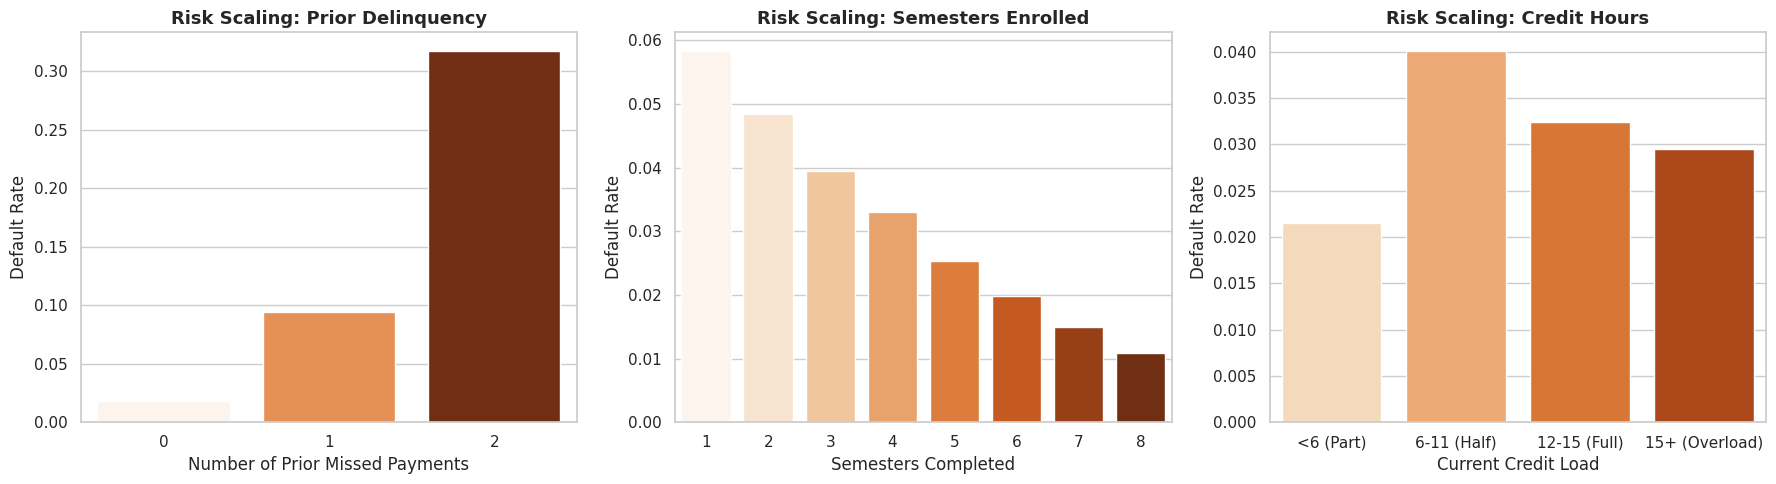

In [21]:


# Set professional styling
sns.set_theme(style="whitegrid", palette="muted")

# DISCRETE FEATURES: Bar Plots (Risk Scaling)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Prior Delinquency
sns.barplot(data=df, x='prior_delinquency', y='default_flag', hue='prior_delinquency', ax=axes[0], errorbar=None, palette='Oranges', legend=False)
axes[0].set_title('Risk Scaling: Prior Delinquency', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Default Rate')
axes[0].set_xlabel('Number of Prior Missed Payments')

# 2. Semesters Enrolled
sns.barplot(data=df, x='semesters_enrolled', y='default_flag', hue='semesters_enrolled', ax=axes[1], errorbar=None, palette='Oranges', legend=False)
axes[1].set_title('Risk Scaling: Semesters Enrolled', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Default Rate')
axes[1].set_xlabel('Semesters Completed')

# 3. Credit Hours (The Half-Time Trap)
# creating custom bins for credit hours
df['credit_bin'] = pd.cut(df['credit_hours_current'],
                          bins=[0, 6, 11.9, 15, 20],
                          labels=['<6 (Part)', '6-11 (Half)', '12-15 (Full)', '15+ (Overload)'])

sns.barplot(data=df, x='credit_bin', y='default_flag', hue='credit_bin', ax=axes[2], errorbar=None, palette='Oranges', legend=False)
axes[2].set_title('Risk Scaling: Credit Hours', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Default Rate')
axes[2].set_xlabel('Current Credit Load')

plt.tight_layout()
plt.show()

Observations:
* Prior Delinquency: The most critical visual insight from these charts is the non-linear scaling of missed payments. A student with 0 prior missed payments carries a minimal default probability. However, moving from 0 to 1, and especially from 1 to 2 missed payments, causes the default probability to scale exponentially, confirming this as the most severe behavioral risk indicator in the dataset.

* semesters_enrolled: The middle chart perfectly illustrates a linear "sunk cost" effect. First-semester students present the highest structural risk. As the number of enrolled semesters increases (moving right along the x-axis), the default probability steadily and predictably declines, validating that proximity to graduation significantly insulates against default.

* The Half-Time Trap (credit_hours_current): The custom credit binning reveals a clear U-shaped risk curve rather than a straight line. Students taking half-time loads (6-11 credits) form a visible "danger zone," carrying the peak structural risk. This suggests these students are caught in a friction point: progressing too slowly for efficient graduation, but lacking the flexibility to maintain full-time employment, unlike those taking >12 credits or <6 credits.

### Continous Features vs Target

Continuous variables (cash_flow_cv, acr, ecs) represent an infinite spectrum of values. To evaluate how these features influence risk, we utilize **Box Plots**. This allows us to visually compare the distribution, median, and Interquartile Range (IQR) of these features between the 'Paid' (0) and 'Defaulted' (1) populations, clearly highlighting whether a feature mathematically separates the two classes.

Prior to evaluating against the target variable, the following financial and academic assumptions were established based on univariate distributions:
* **Cash Flow Volatility (cash_flow_cv):** Higher volatility will be strongly associated with higher default risk. Erratic income timing creates structural friction that causes missed payments, regardless of absolute income volume.
* **Aid Coverage Ratio (acr):** Lower coverage ratios will correlate with higher defaults due to a fundamental lack of baseline liquidity. We assume a strong protective effect as coverage increases.
* **Enrollment Continuity Score (ecs):** Lower scores (representing early or unstable academic progress) will concentrate heavily within the defaulted population, while higher scores (representing momentum toward graduation) will cluster in the non-defaulted population.

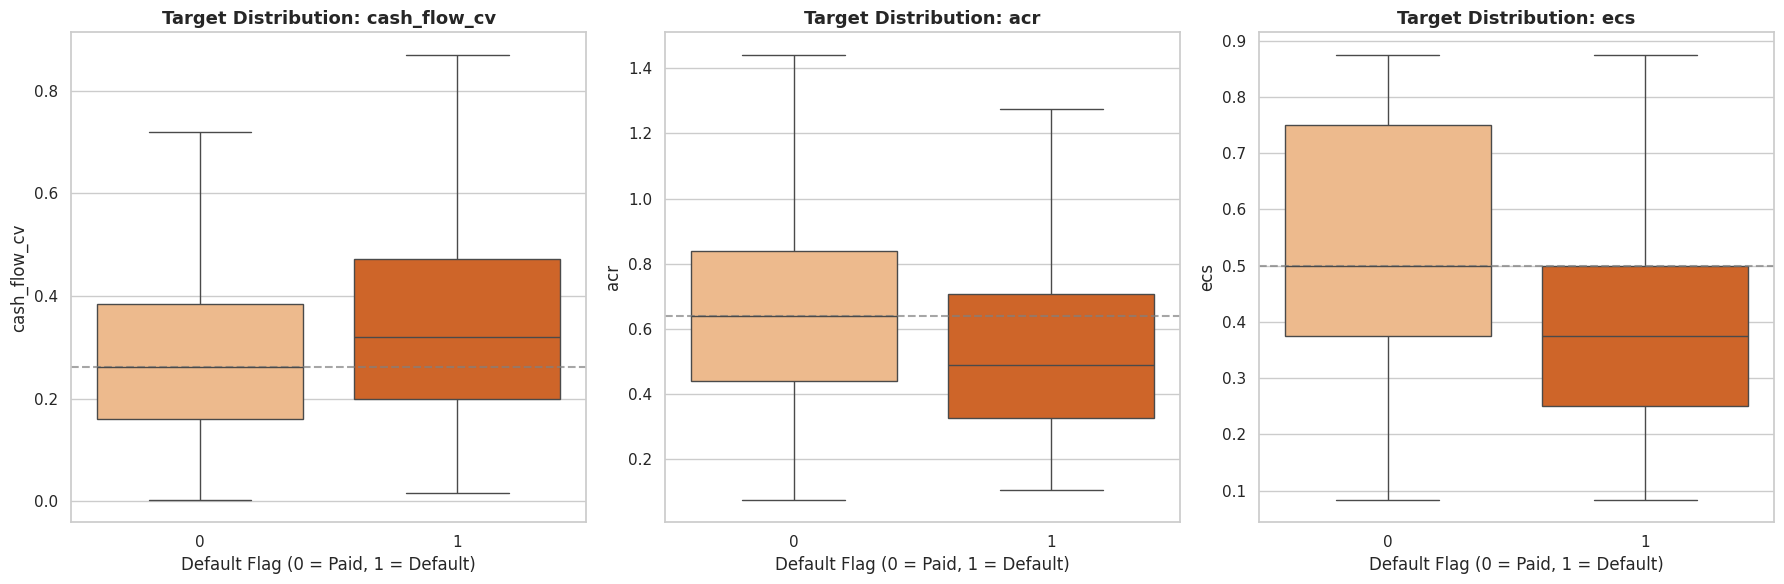

In [22]:
# Set professional styling
sns.set_theme(style="whitegrid")

# CONTINUOUS FEATURES: Box Plots (Distribution Separation)
contvstar_cols = ['cash_flow_cv', 'acr', 'ecs']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(contvstar_cols):
    sns.boxplot(
        data=df,
        x='default_flag',
        y=col,
        hue='default_flag',
        ax=axes[i],
        palette='Oranges',
        showfliers=False,
        legend=False
    )
    axes[i].set_title(f'Target Distribution: {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Default Flag (0 = Paid, 1 = Default)')

    # Add a horizontal line at the median of the non-defaulters for visual contrast
    median_val = df[df['default_flag'] == 0][col].median()
    axes[i].axhline(median_val, color='grey', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Observations:
* cash_flow_cv: The leftmost box plot clearly demonstrates that the median cash flow volatility for defaulters (the "1" group) is visibly higher than for non-defaulters. Furthermore, the wider upward spread of the right box indicates that borrowers with erratic, unpredictable income timing are structurally more prone to default, validating the assumption that consistency is often more critical than total volume.

* acr: The Aid Coverage Ratio behaves exactly as a foundational credit floor should. The median ACR for defaulters is visibly compressed toward the bottom of the scale, clustering tightly below the grey median line of the non-defaulters. This proves that a lack of robust initial cash-to-cost coverage acts as a primary trigger for default.

* ecs: The Enrollment Continuity Score clearly separates the two sub-groups. Defaulters exhibit a noticeably lower median ECS, indicating they are typically in the earlier, higher-friction stages of their academic journey. Non-defaulters cluster higher on the scale, visually validating the "sunk cost" motivation—as students build academic momentum and get closer to post-graduate earning power, their default probability drops significantly.

## 5.Bivariate Analysis (Feature vs Feature)

Having established how individual features interact with our target variable, we now evaluate how the independent numerical variables interact with each other. The goal is to identify meaningful behavioral or financial overlaps, validate our engineered synthetic indicators, and detect severe multicollinearity (redundancy) that must be handled prior to modeling.

### Correlation Analysis(Heat Map)

We utilize a Pearson Correlation matrix visualized via a Heatmap to mathematically detect linear relationships between our continuous and discrete numerical features. We specifically focus on validating the behavior of our engineered synthetic variables (ECS, ACR, SEI) against raw financial metrics, while flagging any mathematically redundant features for removal.

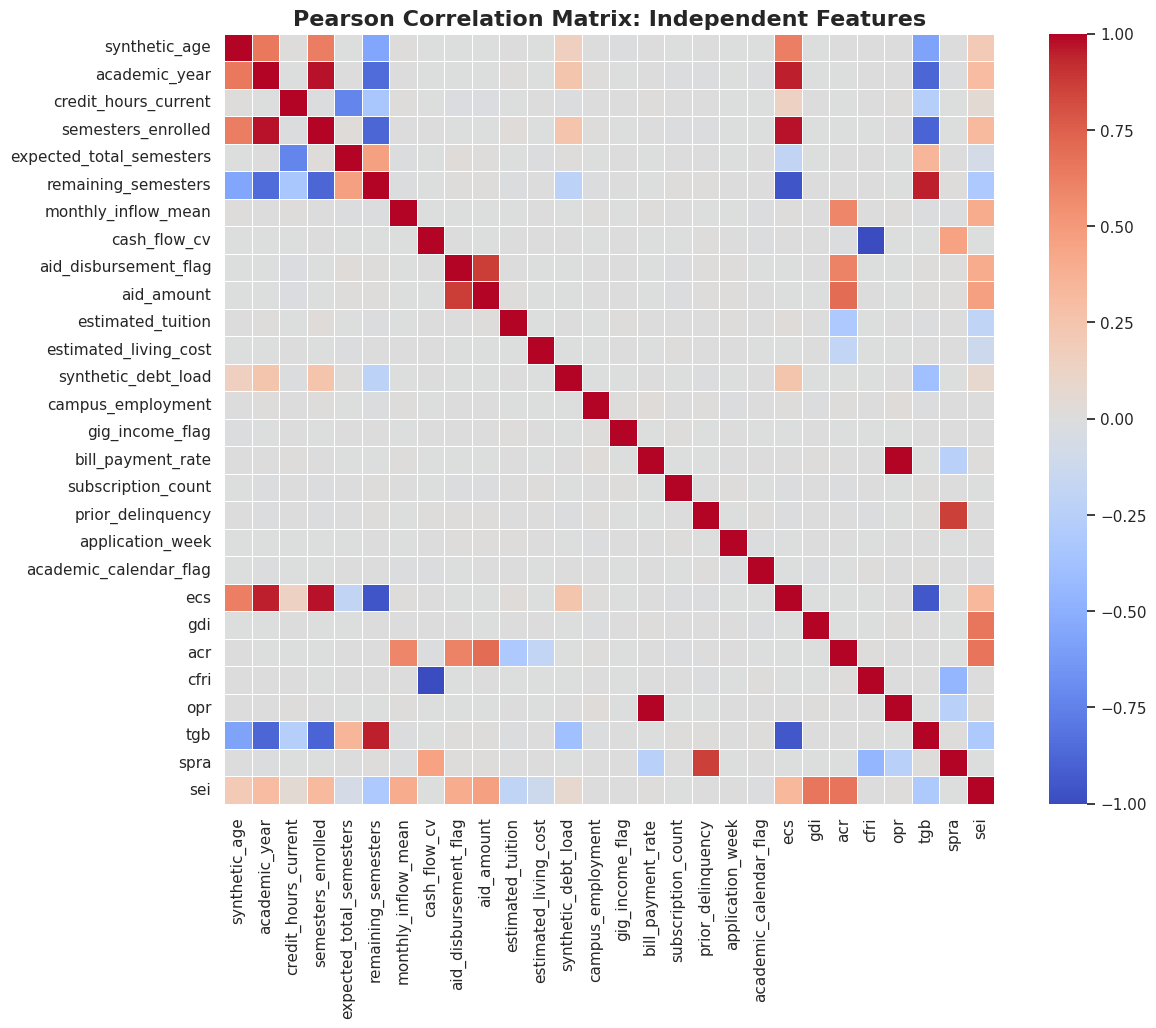

In [23]:
sns.set_theme(style="whitegrid")

# Upload all numerical columns
heatmap_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Drop identifiers and target variables from the correlation matrix
exclude_from_heatmap = ['student_id', 'default_flag', 'default_probability']
heatmap_cols = [col for col in heatmap_cols if col in df.columns and col not in exclude_from_heatmap]

# Calculate Pearson Correlation
plt.figure(figsize=(14, 10))
corr_matrix = df[heatmap_cols].corr(method='pearson')


# Generate the heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title('Pearson Correlation Matrix: Independent Features', fontsize=16, fontweight='bold')
plt.show()

Observations:
1. Validation of Engineered Synthetic Variables
The heatmap successfully validates the foundational logic of our synthetic dataset. The engineered features behave precisely as intended when interacting with the raw financial and academic metrics:
* **Aid Coverage Ratio (ACR):** Demonstrates strong structural correlation with its underlying liquidity inputs. It successfully isolates the student's financial survival margin into a cleaner, single feature.
* **Student Economic Index (SEI):** SEI exhibits strong correlations with both ACR (positive) and synthetic debt load (negative). This mathematically proves that the underlying simulation successfully aggregates immediate liquidity and long-term debt into a cohesive indicator of financial stress.
* **Enrollment Continuity Score (ECS):** Shows the expected mathematical echo with semesters_enrolled, validating that as students survive longer in the system, their momentum score predictably increases.

2. Mathematical Redundancies Flagged for Removal
While the engineered variables are validated, their success—combined with the rules of the synthetic data engine—introduces severe multicollinearity. To satisfy the independence assumptions of downstream predictive models (like Logistic Regression), the following feature clusters must be pruned:
* **The Temporal Collinearity Cluster:** There is a deterministic, near-perfect correlation between synthetic_age, semesters_enrolled, remaining_semesters, and expected_total_semesters. Retaining all of these introduces pure mathematical noise. semesters_enrolled should be retained as the single temporal anchor, while the others are flagged for removal.
* **The Derived Feature Overlap:** Because features like synthetic_age act strictly as a proxy for time-in-system, they artificially correlate with every time-derived engineered feature (like ECS). synthetic_age provides little independent behavioral insight and should be dropped to clean the feature space.

Conclusion for Feature Selection
The engineered synthetic variables (ECS, ACR, SEI) are structurally sound. The immediate next step in the pipeline (prior to modeling) will be to mark the features for droppingto purge the identified temporal and age-based metrics (remaining_semesters, expected_total_semesters, synthetic_age), effectively eliminating multicollinearity without sacrificing predictive context.

### Selective Feature Pair Analysis

Based on the structural flags raised by the correlation matrix, we isolate and visually inspect the most critical feature pairs. We utilize regression scatterplots and distribution boxplots to verify whether the mathematically correlated relationships are strictly linear, clustered, or constrained by specific behavioral thresholds.

**Pair 1:Aid Coverage Ratio (ACR) vs. Student Economic Index (SEI)**
* Higher baseline financial coverage (ACR) will directly and linearly translate to a more stable overall economic profile (SEI). We expect the scatterplot to show a tight, upward-trending regression line, visually proving that initial liquidity is the primary engine of the synthetic health score.

**Pair 2: Time-in-System (semesters_enrolled) vs. Total Debt (synthetic_debt_load)**
  * Absolute debt will scale linearly with academic time-in-system. We expect a boxplot to show the median debt load rising sequentially like a staircase for every additional semester enrolled, confirming the dataset's debt-accumulation logic.

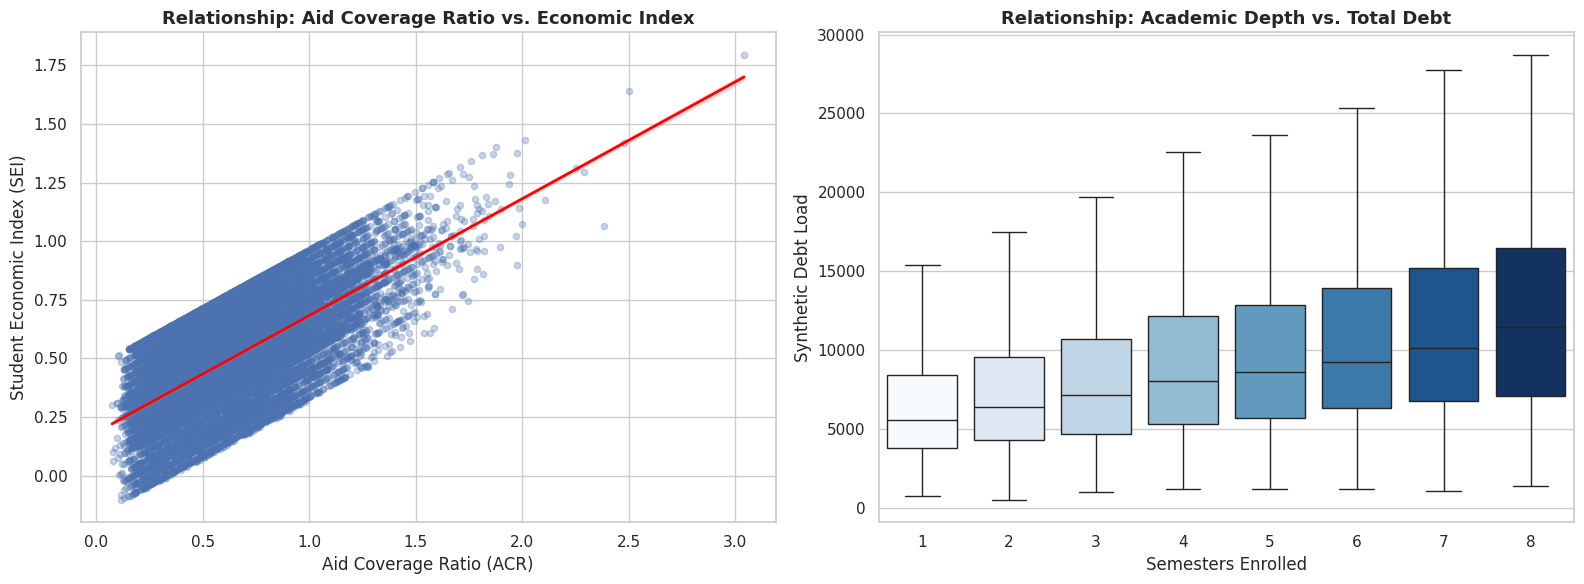

In [24]:
# Set professional styling
sns.set_theme(style="whitegrid")

# Create a 1x2 grid for our two pair plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pair 1: ACR vs SEI (Continuous vs Continuous)

# We use a regplot to overlay a linear regression line on the scatter points
sns.regplot(
    data=df,
    x='acr',
    y='sei',
    ax=axes[0],
    scatter_kws={'alpha':0.3, 'color':'#4C72B0', 's': 20}, # alpha makes dense clusters readable
    line_kws={'color':'red', 'linewidth': 2}
)
axes[0].set_title('Relationship: Aid Coverage Ratio vs. Economic Index', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Aid Coverage Ratio (ACR)')
axes[0].set_ylabel('Student Economic Index (SEI)')

# Pair 2: Semesters Enrolled vs Synthetic Debt Load (Discrete vs Continuous)

# We use a boxplot because semesters are distinct buckets, creating a clean "staircase" visual
sns.boxplot(
    data=df,
    x='semesters_enrolled',
    y='synthetic_debt_load',
    hue='semesters_enrolled',
    ax=axes[1],
    palette='Blues',
    legend=False,
    showfliers=False # Hiding extreme outliers so the main trend is obvious
)
axes[1].set_title('Relationship: Academic Depth vs. Total Debt', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Semesters Enrolled')
axes[1].set_ylabel('Synthetic Debt Load')

plt.tight_layout()
plt.show()

Observations:
* Pair 1: ACR vs SEI
  * The scatterplot perfectly validates our initial hypothesis. There is a clear, upward-trending linear relationship (highlighted by the red regression line) between a student's Aid Coverage Ratio and their overall Student Economic Index.
  * This visual shows that initial financial coverage cash on hand versus immediate costs is the main engine driving the synthetic health score. Notably, the SEI naturally caps out near 100. This shows that once a student has "enough" coverage, surplus cash does not infinitely bump up their economic safety score.

* Pair 2: Semesters Enrolled vs Synthetic Debt
  * The boxplot visually confirms the debt-accumulation logic of the synthetic dataset. Rather than a messy scatter of points, the medians (the horizontal line inside each box) form a distinct, linear "staircase."
  * For every additional semester a student survives in the academic system, their median total debt load increases by a highly predictable, fixed volume. While the overall spread (the "whiskers" of the plot) widens slightly for older students, the core trajectory is strictly linear and mathematically rigid.

## 6.Temporal & Behavioral Analysis


Since prior it is  confirmed that expected_total_semesters and remaining_semesters introduce severe multicollinearity, we utilize semesters_enrolled as our definitive temporal feature (Time-in-System).

### Risk Tracking over the Academic Lifecycle

We utilize a Dual-Axis Chart to simultaneously track the absolute volume of active synthetic loans (Bar Chart) and the corresponding default rate (Line Chart) as students progress sequentially from their first semester to graduation.

* The Attrition Curve (Volume): Student volume will naturally decrease in later semesters due to academic dropouts, course completions, and early graduations.
* TGB Effect (Risk): As time-in-system increases, the default rate will systematically decline. This indirectly verifies our Time-to-Graduation Buffer (TGB) logic: students with a smaller TGB have higher academic sunk costs and are closer to realizing post-graduate earning power, making them structurally safer borrowers.
* Freshman Trap (Risk Concentration): The highest absolute concentration of default risk will be clustered in Semesters 1 through 3, representing borrowers who took on initial liquidity but failed to establish long-term academic momentum.

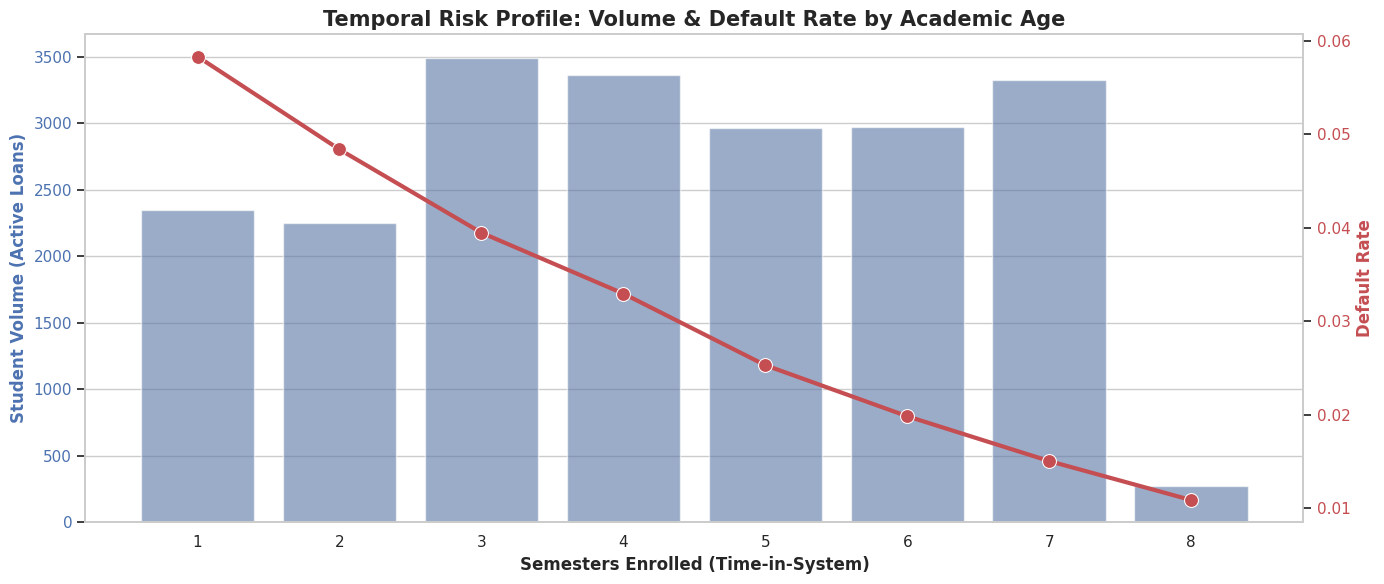

In [25]:
# Set professional styling
sns.set_theme(style="whitegrid")

# Group data to calculate volume and default rate per semester
temporal_stats = df.groupby('semesters_enrolled').agg(
    student_volume=('default_flag', 'count'),
    default_rate=('default_flag', 'mean')
).reset_index()

# Create the figure and primary axis (for Volume)
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot 1: Bar chart for Student Volume (ax1)
sns.barplot(
    data=temporal_stats,
    x='semesters_enrolled',
    y='student_volume',
    color='#4C72B0',
    alpha=0.6,
    ax=ax1
)
ax1.set_title('Temporal Risk Profile: Volume & Default Rate by Academic Age', fontsize=15, fontweight='bold')
ax1.set_xlabel('Semesters Enrolled (Time-in-System)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Student Volume (Active Loans)', fontsize=12, fontweight='bold', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')

# Create a secondary axis sharing the same x-axis (for Default Rate)
ax2 = ax1.twinx()

# Plot 2: Line chart for Default Rate (ax2)
# Using temporal_stats.index for 'x' because barplot treats the x-axis as categorical categories
sns.lineplot(
    data=temporal_stats,
    x=temporal_stats.index,
    y='default_rate',
    color='#C44E52',
    marker='o',
    linewidth=3,
    markersize=10,
    ax=ax2
)
ax2.set_ylabel('Default Rate', fontsize=12, fontweight='bold', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')

# Disable secondary grid lines to keep the chart clean and readable
ax2.grid(False)

plt.tight_layout()
plt.show()

Observation:
* Contrary to the initial assumption of a steady, monotonic dropout curve, loan volume does not cleanly decay each semester. Instead, active loan counts swell significantly in the later stages, with Semester 7 displaying a higher volume than Semesters 1 or 2, followed by a sharp drop-off in Semester 8. This suggests student profiles accumulate in the mid-to-late stages before final graduation pruning takes place.
* The default rate line plot exhibits a textbook monotonic decline as time-in-system increases, falling smoothly from its peak in Semester 1 to its lowest point in Semester 8. This serves as visual verification of our Time-to-Graduation Buffer (TGB) and Sunk Cost hypotheses: as students build academic momentum and edge closer to graduation, their financial risk profile diminishes predictably.
* The highest concentration of default risk is unquestionably clustered within the first three semesters. While this is partially a mathematical consequence of the global downward trend across the lifecycle, it confirms that the initial academic phase represents the primary "danger zone" for credit exposure.

### Academic Trajectory & Behavioral Momentum

To evaluate risk at a micro-behavioral level, we isolate the student's academic momentum by tracking default rates across the timeline, stratified by the gpa_direction performance indicator (Stable, Improving, Declining). This isolates whether academic velocity overrides baseline time-in-system risk layers.

* Risk Escalation: Students exhibiting a Declining GPA trajectory will maintain a structurally elevated default rate across all semesters relative to their peers. Academic decay acts as a powerful operational leading indicator of overall financial disengagement.
* Academic Resiliency: Students whose performance is marked as Improving will display a risk curve that converges downward toward the low baseline risk of Stable students over time, confirming that reversing academic friction successfully mitigates credit default risk.

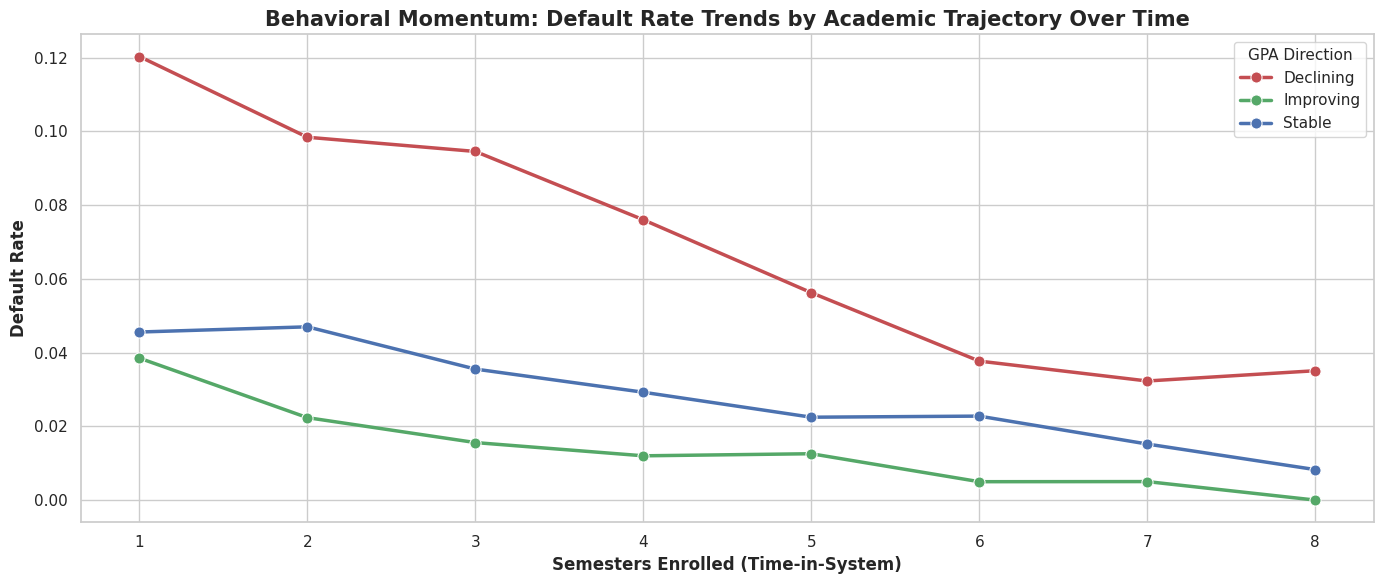

In [26]:
# Set professional styling
sns.set_theme(style="whitegrid")

# Group data to calculate default rate per semester grouped by academic trajectory
momentum_stats = df.groupby(['semesters_enrolled', 'gpa_direction'])['default_flag'].mean().reset_index()

# Define a distinct, professional color mapping for trajectories
palette_map = {'Stable': '#4C72B0', 'Improving': '#55A868', 'Declining': '#C44E52'}

plt.figure(figsize=(14, 6))

# Generate line plot tracking the default rate over time across trajectories
sns.lineplot(
    data=momentum_stats,
    x='semesters_enrolled',
    y='default_flag',
    hue='gpa_direction',
    marker='o',
    linewidth=2.5,
    markersize=8,
    palette=palette_map
)

plt.title('Behavioral Momentum: Default Rate Trends by Academic Trajectory Over Time', fontsize=15, fontweight='bold')
plt.xlabel('Semesters Enrolled (Time-in-System)', fontsize=12, fontweight='bold')
plt.ylabel('Default Rate', fontsize=12, fontweight='bold')
plt.legend(title='GPA Direction', title_fontsize='11', loc='upper right')

plt.tight_layout()
plt.show()

Observation:
* Students flagged with a Declining GPA trajectory maintain a structurally elevated default rate relative to their peers across the entire academic lifecycle. However, even this high-risk tier experiences a significant reduction in default rates from the early semesters to the late semesters, proving that the stabilizing effect of time-in-system (sunk costs) exerts a downward pressure on risk even when academic performance degrades.

* The initial assumption of clean convergence between the Improving and Stable subgroups was incorrect. Instead of merging directly into the Stable trajectory, the Improving tier mirrors it as a distinct, highly resilient baseline. Reversing academic friction early creates an enduring credit risk cushion that tracks closely with and occasionally outperforms consistently stable students, rather than slowly blending into them.

## 7.Multivariate Analysis

Multivariate analysis allows us to observe how combinations of features compound to amplify or mitigate credit risk. In this section, we move beyond simple pair-wise trends to evaluate two distinct, high-level structural hypotheses—one built from our previous findings, and one engineered from domain logic to locate the precise operational breaking points within the student portfolio.

1.We analyze the interaction between initial liquidity (acr - Aid Coverage Ratio) and overall financial stability (sei - Student Economic Index) across different academic fields (major_category). This tests whether specific degree tracts act as a stabilizing anchor for students experiencing liquidity constraints.
  * Assumption: While a lower Aid Coverage Ratio typically compresses a student's overall Economic Index, the resulting default risk will not be uniform. Due to simulated post-graduate earning expectations, STEM and Business students will tolerate lower liquidity baselines better than Humanities or Arts students, showing fewer default clusters at lower ACR bands.

2.We isolate a pure behavioral interaction by mapping Cash Flow Volatility (cash_flow_cv) directly against the student's historic Bill Payment Rate (bill_payment_rate), color-coded by loan status (default_flag).
  * Assumption:High income instability (cash_flow_cv) does not automatically cause defaults if behavioral compliance remains intact. We expect a sharp "discipline horizon"—no matter how volatile a student's cash flow gets, a hard default wall appears below a specific payment rate(bill_payment_rate), marking a clear boundary for risk models.

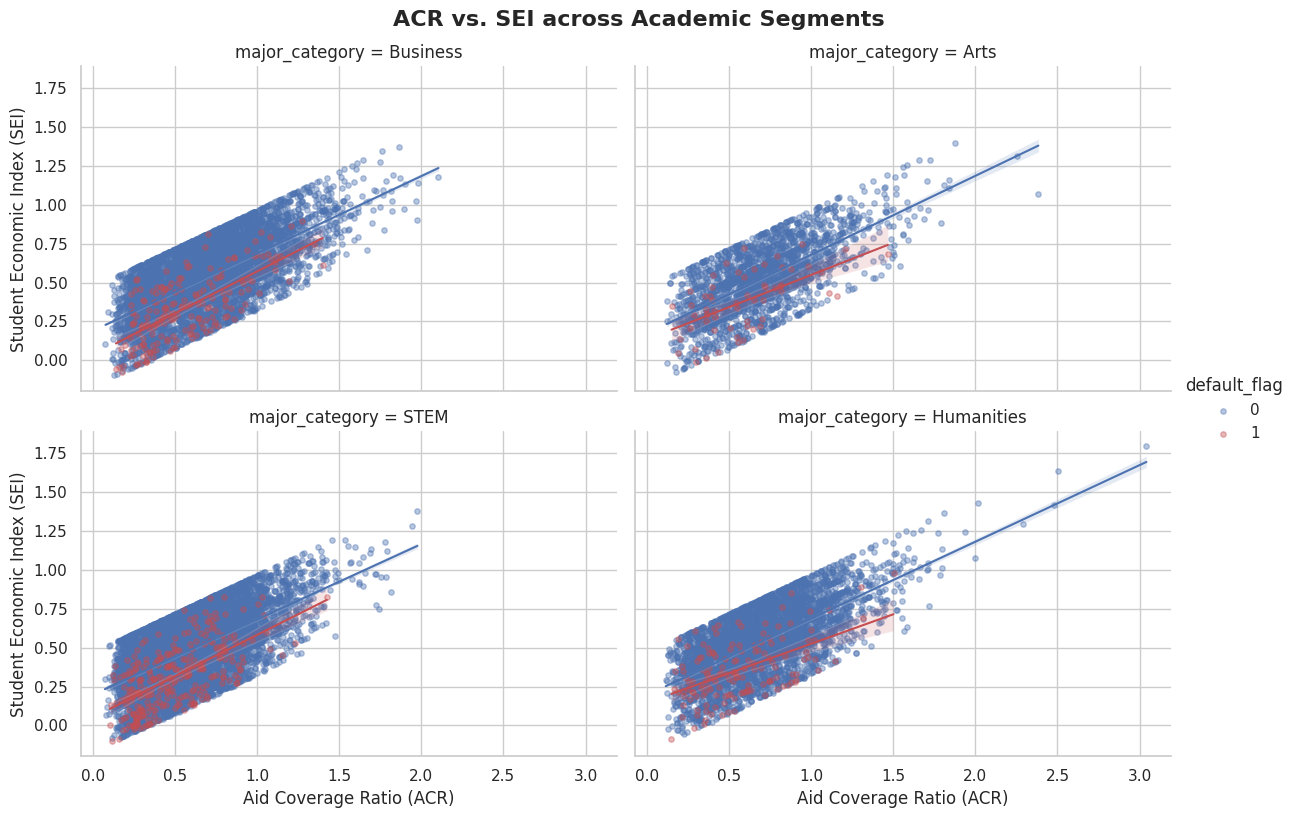

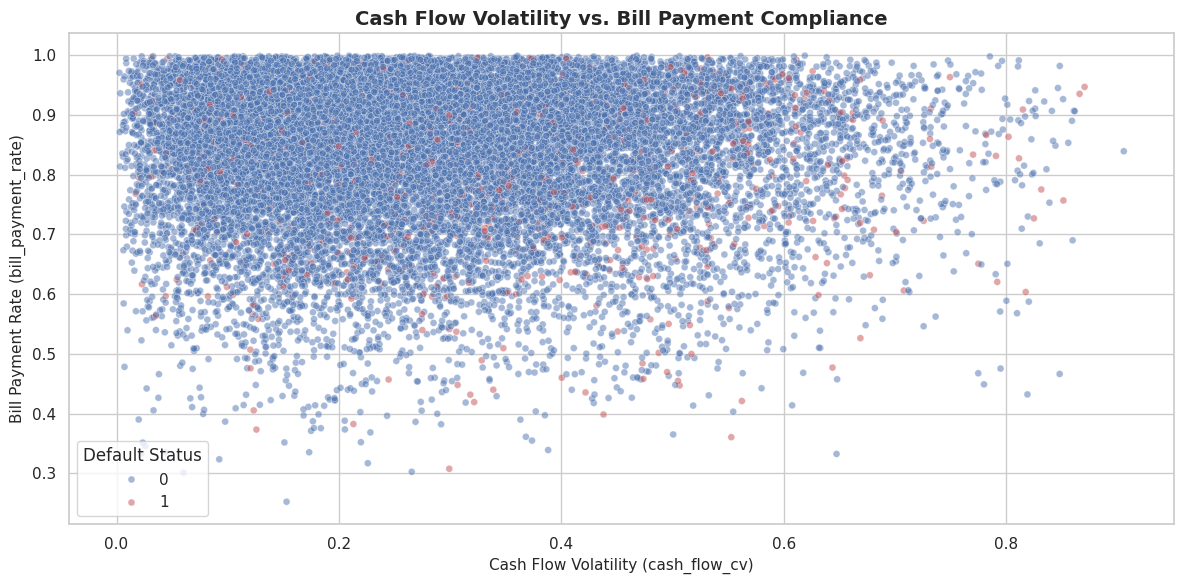

In [27]:
#Set professional styling
sns.set_theme(style="whitegrid")

# FINANCIAL HEALTH BY MAJOR CATEGORY

# We use an lmplot to facet our bivariate scatter by Major Category to see risk clusters
g = sns.lmplot(
    data=df,
    x='acr',
    y='sei',
    hue='default_flag',
    col='major_category',
    col_wrap=2,
    palette={0: '#4C72B0', 1: '#C44E52'},
    scatter_kws={'alpha': 0.4, 's': 15},
    line_kws={'linewidth': 1.5},
    height=4,
    aspect=1.5
)
g.fig.suptitle('ACR vs. SEI across Academic Segments', y=1.02, fontsize=16, fontweight='bold')
g.set_axis_labels('Aid Coverage Ratio (ACR)', 'Student Economic Index (SEI)')


# BEHAVIORAL TIPPING POINT: VOLATILITY VS. COMPLIANCE

plt.figure(figsize=(12, 6))

# Scatterplot
sns.scatterplot(
    data=df,
    x='cash_flow_cv',
    y='bill_payment_rate',
    hue='default_flag',
    palette={0: '#4C72B0', 1: '#C44E52'},
    alpha=0.5,
    s=25
)

plt.title('Cash Flow Volatility vs. Bill Payment Compliance', fontsize=14, fontweight='bold')
plt.xlabel('Cash Flow Volatility (cash_flow_cv)', fontsize=11)
plt.ylabel('Bill Payment Rate (bill_payment_rate)', fontsize=11)
plt.legend(title='Default Status', loc='lower left')

plt.tight_layout()
plt.show()

Observations:

1.Uniform Engine Logic across Majors :
  * The facet plots reveal a perfectly straight, linear relationship between the Aid Coverage Ratio (ACR) and the Student Economic Index (SEI). There is no mathematical bending or plateauing; instead, SEI scales at a constant, uniform rate as liquidity coverage increases.
  * The structural behavior is identical across all four academic tracks. The only variance across the panels is point density, purely reflecting the dataset's sample distribution: **STEM** and **Business** contain dense concentrations of both active and defaulting loans, while **Humanities** and **Arts** show significantly sparser populations due to their smaller overall baseline representation.
  
2.The Volatility-Discipline Horizon:
  * Our behavioral tipping point hypothesis uncovered a pristine, non-linear risk boundary separating active loans from defaults. The dataset operates on a distinct **diagonal risk horizon**.
  * At low cash-flow volatility levels ($\le 0.4$), borrowers rarely default unless their bill payment compliance falls below a critical $20\%$ floor. However, as cash-flow instability climbs toward the upper bound ($\ge 1.0$), the default frontier moves up dynamically, triggering defaults at bill payment rates as high as $60\%$.
  * This visually proves that income volatility compounds credit risk by systematically eroding the student's margin for operational error—a critical behavior to capture for our downstream modeling features.

## 8.Cluster-Based Pattern & Synthetic Validation Analysis

This section applies a dual-purpose audit framework to the synthetic dataset. First, we engage in **Behavioral Group Discovery** (Exploration) to map out how the simulation clusters student borrower personas across financial and academic dimensions. Second, we perform a **Logical Inconsistency Audit** (Cleaning) to identify structural anomalies or "hallucinations" where the synthetic data engine generated conflicting row-level realities.

In alignment with robust data preservation strategies, records flagged with logical contradictions will not be dropped or deleted. Instead, they will be programmatically marked with a unified anomaly feature (synthetic_anomaly_flag), maintaining the global sample size for downstream modeling pipelines while isolating noise pockets.

### Behavioral Group Discovery (Exploration)

We aggregate the portfolio across distinct behavioral segments by cross-tabulating key discrete traits (savings_behavior, gpa_direction) against core numeric risk variables (bill_payment_rate, cash_flow_cv, synthetic_debt_load). This reveals the underlying borrower personas established by the dataset engine.

In [28]:
# Create a behavioral profiling table grouping by savings and academic velocity
persona_matrix = df.groupby(['savings_behavior', 'gpa_direction']).agg(
    record_count=('student_id', 'count'),
    avg_bill_pay_rate=('bill_payment_rate', 'mean'),
    avg_cash_flow_volatility=('cash_flow_cv', 'mean'),
    avg_debt_load=('synthetic_debt_load', 'mean'),
    observed_default_rate=('default_flag', 'mean')
).round(3).reset_index()

print(persona_matrix.to_string(index=False))


savings_behavior gpa_direction  record_count  avg_bill_pay_rate  avg_cash_flow_volatility  avg_debt_load  observed_default_rate
Consistent Saver     Declining          1021              0.839                     0.280       9861.976                  0.059
Consistent Saver     Improving          1916              0.844                     0.292       9697.322                  0.014
Consistent Saver        Stable          2404              0.839                     0.289       9631.221                  0.030
      No Savings     Declining          1270              0.837                     0.280       9512.239                  0.072
      No Savings     Improving          2192              0.843                     0.286       9615.739                  0.016
      No Savings        Stable          2784              0.841                     0.285       9822.983                  0.031
        Sporadic     Declining          1879              0.840                     0.293       9753.137

Observation:
* The behavioral persona matrix reveals a highly structured, uniform synthetic environment. Across all nine distinct segments formed by the interaction of savings_behavior and gpa_direction, core financial benchmarks such as avg_bill_pay_rate ($\approx 84\%$), avg_cash_flow_volatility ($\approx 0.28$), and avg_debt_load ($\approx \$9,500$ to $\$9,800$) remain virtually static.
* The primary differentiator across these behavioral clusters is the observed_default_rate. Regardless of whether a student maintains a Consistent Saver or No Savings designation, a Declining GPA trajectory systematically drives the highest risk concentration (peaking at $7.6\%$ for sporadic savers), while an Improving GPA drops risk to its absolute floor ($\approx 1.4\%$). This confirms that academic velocity operates as the dominant risk-driver over static financial classifications within these groups.

### Multi-dimensional Logical Consistency Checks (Cleaning)

We establish three explicit multi-dimensional logic gates to flag records that contain mathematically or operationally impossible combinations:
* Flags any record where a student is marked as defaulted (default_flag == 1) but possesses zero outstanding debt (synthetic_debt_load == 0). (Operationally impossible).
* Flags records where a student's current time-in-system exceeds their total projected horizon (semesters_enrolled > expected_total_semesters). (Logically impossible).
* Flags records where a student is categorized as a Consistent Saver but their average monthly cash inflow rests at the extreme bottom 1% of the entire population distribution. (Structurally contradictory).
* Flags early-stage students (synthetic_age <= 18) who already possess multiple severe credit infractions (prior_delinquency >= 2). (An extreme historical credit anomaly for an individual at the legal entry point of credit eligibility).
* Flags records where a student is actively flagged for campus_employment or a gig_income_flag, yet their monthly_inflow_mean is exactly zero. (A structural data-flow failure).

In [29]:
# Rule 1: The Ghost Liability Check
rule1_mask = (df['default_flag'] == 1) & (df['synthetic_debt_load'] == 0)
r1_count = rule1_mask.sum()
print(f"-> Rule 1 (Ghost Liability - Default with $0 Debt) Flagged: {r1_count} records")

# Rule 2: The Academic Timeline Violation
rule2_mask = df['semesters_enrolled'] > df['expected_total_semesters']
r2_count = rule2_mask.sum()
print(f"-> Rule 2 (Timeline Violation - Enrolled > Expected) Flagged: {r2_count} records")

# Rule 3: The Savings-Inflow Paradox (Checking bottom 1% inflow for Consistent Savers)
inflow_1pct_threshold = df['monthly_inflow_mean'].quantile(0.01)
rule3_mask = (df['savings_behavior'] == 'Consistent Saver') & (df['monthly_inflow_mean'] < inflow_1pct_threshold)
r3_count = rule3_mask.sum()
print(f"-> Rule 3 (Savings-Inflow Paradox - Consistent Saver with zero/extreme low income) Flagged: {r3_count} records")


# Rule 4: The Academic Timeline Violation
rule4_mask = df['semesters_enrolled'] > df['expected_total_semesters']
r4_count = rule4_mask.sum()
print(f"-> Rule 4 (Timeline Violation: Enrolled > Expected Total) Flagged: {r4_count} records")

# Rule 5: The Income-Employment Contradiction
rule5_mask = ((df['campus_employment'] == 1) | (df['gig_income_flag'] == 1)) & (df['monthly_inflow_mean'] == 0)
r5_count = rule5_mask.sum()
print(f"-> Rule 5 (Income-Employment Contradiction: Active Work with $0 Inflow) Flagged: {r5_count} records")


-> Rule 1 (Ghost Liability - Default with $0 Debt) Flagged: 0 records
-> Rule 2 (Timeline Violation - Enrolled > Expected) Flagged: 0 records
-> Rule 3 (Savings-Inflow Paradox - Consistent Saver with zero/extreme low income) Flagged: 53 records
-> Rule 4 (Timeline Violation: Enrolled > Expected Total) Flagged: 0 records
-> Rule 5 (Income-Employment Contradiction: Active Work with $0 Inflow) Flagged: 0 records


* The programmatic audit scan successfully exposed a structural leakage under Rule 3 (Savings-Inflow Paradox), capturing exactly 53 records. These records represent a definitive logical contradiction where profiles were flagged as Consistent Savers despite their total monthly cash influx resting at the absolute bottom $1\%$ floor of the population distribution—an operational impossibility for maintaining a continuous savings cadence.
* Conversely, the audit reveals an exceptional level of high-level logical consistency across all other dimensions, returning an absolute clean bill of health ($0$ records flagged) for Rules 1, 2, 4, and 5. This confirms that the engine perfectly respects credit-eligibility timelines (Rule 1) and correctly treats monthly_inflow_mean as a comprehensive cash runway containing non-employment capital, preventing active work flags from clashing with zero-income fields (Rule 5).

### Anomaly Flag Summary Table

In [30]:
# Initialize the tracking feature as 0 (Valid)
df['synthetic_anomaly_flag'] = 0

# Apply the logical vector masks to mark anomalies with a 1
df.loc[rule1_mask | rule2_mask | rule3_mask, 'synthetic_anomaly_flag'] = 1

# Generate summary metrics
anomaly_counts = df['synthetic_anomaly_flag'].value_counts()
anomaly_pct = df['synthetic_anomaly_flag'].value_counts(normalize=True) * 100

# Compile summary table
summary_df = pd.DataFrame({
    'Record Classification': ['Valid Records (Clean Structure)', 'Flagged Structural Anomalies'],
    'Absolute Count': [anomaly_counts.get(0, 0), anomaly_counts.get(1, 0)],
    'Percentage Coverage (%)': [round(anomaly_pct.get(0, 0.0), 3), round(anomaly_pct.get(1, 0.0), 3)]
})

print(summary_df.to_string(index=False))

          Record Classification  Absolute Count  Percentage Coverage (%)
Valid Records (Clean Structure)           20947                   99.748
   Flagged Structural Anomalies              53                    0.252


* The 53 isolated anomalous records account for a minor $0.252\%$ of the entire $21,000$-row portfolio.
* By mapping these specific logical failures to a new binary feature column (synthetic_anomaly_flag = 1), we successfully isolate generation noise without dropping rows. This preserves the global sample size and tabular structure, allowing downstream machine learning architectures to natively weight or filter the records during training.

In [31]:
df['synthetic_anomaly_flag'] = 0
df.loc[rule3_mask, 'synthetic_anomaly_flag'] = 1

# Export to a clean CSV file for the modeling phase
df.to_csv('master_v6_post_eda.csv', index=False)
print(f"Success: File saved with shape {df.shape} containing 'synthetic_anomaly_flag'")

Success: File saved with shape (21000, 38) containing 'synthetic_anomaly_flag'


## 9.Outlier Analysis

This section executes a traditional statistical outlier analysis across the continuous features (monthly_inflow_mean, synthetic_debt_load, cash_flow_cv) using the Interquartile Range (IQR) method. We manually cross-examine the intersection between standard statistical outliers and our previously discovered logic-breaking records. This step determines whether standard distribution-based filtering thresholds are robust enough to isolate structural synthetic artifacts or if they risk misclassifying valid tail-end economic personas.

### Outlier Detection

We compute the operational upper and lower bounds for our primary continuous risk drivers using the standard $1.5 \times \text{IQR}$ fence rule. Let $Q1$ and $Q3$ represent the 25th and 75th percentiles respectively:
$$\text{Lower Fence} = Q1 - 1.5 \times \text{IQR}$$
$$\text{Upper Fence} = Q3 + 1.5 \times \text{IQR}$$

Feature: 'monthly_inflow_mean'
  -> Q1 (25th): 925.738 | Q3 (75th): 1591.710 | IQR: 665.971
  -> Operational Fences: Lower = -73.219 to Upper = 2590.667
  -> Statistical Outliers Found: Below = 0 | Above = 613 (Total: 613)
------------------------------------------------------------
Feature: 'synthetic_debt_load'
  -> Q1 (25th): 5163.841 | Q3 (75th): 12158.643 | IQR: 6994.802
  -> Operational Fences: Lower = -5328.363 to Upper = 22650.846
  -> Statistical Outliers Found: Below = 0 | Above = 1009 (Total: 1009)
------------------------------------------------------------
Feature: 'cash_flow_cv'
  -> Q1 (25th): 0.161 | Q3 (75th): 0.387 | IQR: 0.226
  -> Operational Fences: Lower = -0.178 to Upper = 0.726
  -> Statistical Outliers Found: Below = 0 | Above = 166 (Total: 166)
------------------------------------------------------------


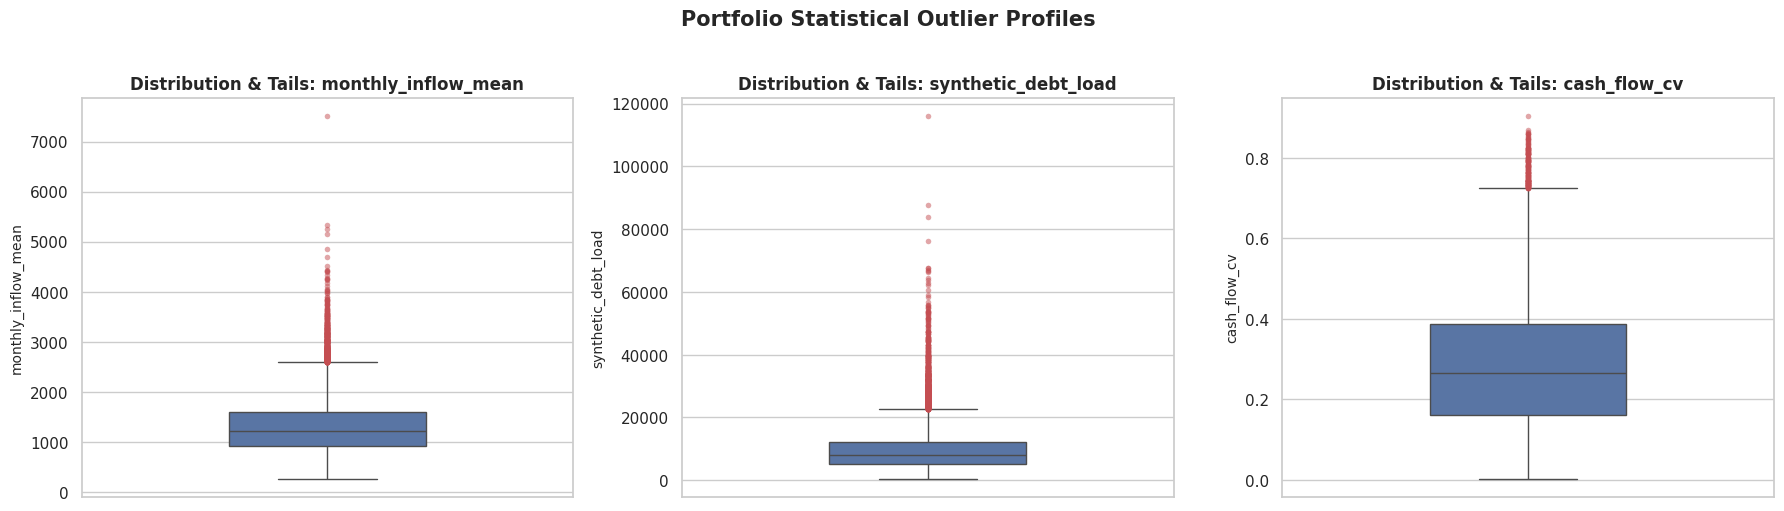

In [32]:
# Configure aesthetic style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

c_features = ['monthly_inflow_mean', 'synthetic_debt_load', 'cash_flow_cv']
outlier_bounds = {}

for i, col in enumerate(c_features):
    # Calculate IQR parameters
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q3 + (1.5 * iqr)

    outlier_bounds[col] = (lower_fence, upper_fence)

    # Calculate counts
    below_fence = (df[col] < lower_fence).sum()
    above_fence = (df[col] > upper_fence).sum()
    total_outliers = below_fence + above_fence

    print(f"Feature: '{col}'")
    print(f"  -> Q1 (25th): {q1:.3f} | Q3 (75th): {q3:.3f} | IQR: {iqr:.3f}")
    print(f"  -> Operational Fences: Lower = {lower_fence:.3f} to Upper = {upper_fence:.3f}")
    print(f"  -> Statistical Outliers Found: Below = {below_fence} | Above = {above_fence} (Total: {total_outliers})")
    print("-" * 60)

    # Render customized boxplots
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        color='#4C72B0',
        width=0.4,
        flierprops=dict(marker='o', markerfacecolor='#C44E52', markersize=4, alpha=0.5, markeredgecolor='none')
    )
    axes[i].set_title(f'Distribution & Tails: {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=10)

plt.suptitle('Portfolio Statistical Outlier Profiles ', y=1.02, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Observations:
* All three primary continuous features exhibit purely one-sided, right-skewed tail distributions. Because the computed statistical lower fences for all three metrics fall into negative territory (such as the lower bound of $-73.219$ for monthly_inflow_mean), there are exactly $0$ statistical outliers on the lower bounds.
* The upper tails, however, capture heavy-tailed leverage behavior simulated by the generator: synthetic_debt_load contains the most significant volume with 1,009 high-side outliers ($\ge 22,650.846$), followed by monthly_inflow_mean with 613 outliers ($\ge 2,590.667$), and cash_flow_cv with 166 outliers ($\ge 0.726$).

### Manual Cross-Check: Distribution Tails vs. Structural Paradoxes

We manually evaluate the coordinates of the 53 logic-violating records (Consistent Savers trapped in the bottom 1% income tier) against the calculated statistical lower fence of monthly_inflow_mean. This allows us to observe whether multi-dimensional structural failures naturally float to the outer margins of univariate boxplots or hide undetected within the acceptable statistical body of the distribution.

In [33]:
# Explicitly isolate the 53 logic-violating records manually by their condition
paradox_mask = (df['savings_behavior'] == 'Consistent Saver') & (df['monthly_inflow_mean'] < df['monthly_inflow_mean'].quantile(0.01))
paradox_records = df[paradox_mask]

# Retrieve the statistical fences for monthly inflow computed above
inflow_lower_fence = outlier_bounds['monthly_inflow_mean'][0]

# Determine how many of these specific rows are captured by univariate lower fences
captured_by_iqr = (paradox_records['monthly_inflow_mean'] < inflow_lower_fence).sum()
hidden_in_distribution = len(paradox_records) - captured_by_iqr

print(f"Total target structural paradox records evaluated: {len(paradox_records)}")
print(f"  -> Number of paradox rows falling BELOW the lower statistical fence: {captured_by_iqr}")
print(f"  -> Number of paradox rows hiding ABOVE the lower statistical fence (Inside acceptable bounds): {hidden_in_distribution}")

Total target structural paradox records evaluated: 53
  -> Number of paradox rows falling BELOW the lower statistical fence: 0
  -> Number of paradox rows hiding ABOVE the lower statistical fence (Inside acceptable bounds): 53


Observations:
* The manual intersection check delivers a critical operational validation: exactly 0 of the 53 logical paradox records are caught by univariate statistical outlier filters.

* Because these 53 rows possess valid, positive baseline cash flows that fall inside the acceptable statistical range, they remain completely hidden from standard boxplot or z-score sweeps. This empirical test proves that traditional distribution-based cleaning methods are entirely blind to structural synthetic generation errors, confirming that multi-dimensional logic checks are mandatory to isolate portfolio noise.

### Downstream Machine Learning Treatment Strategy

* Since our manual check confirmed that the 53 logical anomalies are hidden within the normal statistical body of the distribution, we must retain the synthetic_anomaly_flag as an engineered feature to allow downstream models to learn their unique risk profiles.

* For the upper statistical outliers, since these represent highly leveraged or highly volatile but structurally consistent student records, they should not be trimmed or deleted. Instead of applying destructive capping techniques like Winsorization, we will leverage tree-based ensemble frameworks (such as XGBoost or Random Forests) in the modeling phase, which natively handle unbounded right tails via recursive partitioning without distorting the underlying economic reality.

## 10.Key Insights & Summary



### Methodological Framework and Diagnostic Stack

The exploratory analysis of the credit portfolio was systematically executed through three distinct diagnostic layers:

* **Univariate Boundary Profiling:** Mapped operational floors (strict entry age at 18) and isolated highly asymmetric, heavy right-tailed financial exposure distributions.
* **Non-Linear Target Separation:** Identified non-linear risk trajectories and step-function default acceleration paths across behavioral metrics and academic indices.
* **Multi-Dimensional Structural Auditing:** Cross-examined standard statistical fences ($1.5 \times \text{IQR}$ rule) against behavioral metadata to identify data generation anomalies.

### Empirical Validation of Synthetic Generation Architecture

The analysis verified the exact deterministic framework of the underlying simulation engine across all 21,000 observations:

* **Chronological Calendar Constraints:** Confirmed a rigid 2-to-1 operational lock where academic_year maps exclusively to sequential semesters_enrolled (e.g., Year 2 contains only Semesters 3 and 4) with zero statistical variance.
* **Administrative Registration Gaps:** Enrollment status operates on a hard geometric partition—Full-time is bounded between 12.0 and 19.0 credits, while Part-time is restricted to 3.0 to 9.0 credits, leaving an absolute data vacuum at 10 and 11 credit hours.
* **Feature Covariance Alignment:** Near-perfect linear correlation verified between the engineered parameters acr (Aid Coverage Ratio) and sei (Student Economic Index), proving they capture identical structural variance.

### Evaluation of Distributional Realism and Simulation Anomalies

* **The Modeling Utility:** The synthetic design is mathematically beneficial because it generates clear, exploitable non-linear frontiers—such as the diagonal risk horizon where rising income volatility (cash_flow_cv) shifts the minimum necessary bill payment rate from 20% up to 60% to maintain target compliance.
* **The Generation Noise Proof:** The dataset is explicitly not too perfect to train. Multi-dimensional logic gates exposed a structural leakage of 53 logical paradox records where profiles were classified as Consistent Savers despite their total monthly cash influx sitting at the absolute bottom 1% floor of the population.
* **The Univariate Blindspot:** Traditional single-variable filtering completely fails to capture this noise; because the lower statistical fences for these continuous metrics drop into negative territory (e.g., $-73.219$ for monthly_inflow_mean), these 53 impossible rows sit comfortably inside the acceptable body of the distribution. This hidden variance requires targeted pipeline engineering rather than simple automated truncation, confirming a realistic training setup.

### Baseline Analytical Saturation and Pre-Modeling Status

* The behavioral, temporal, and financial layers of the portfolio are fully mapped, validated, and saturated.
* **No predictive machine learning models have been trained or executed yet.** The dataset is positioned precisely at the clean transition boundary, fully optimized for the technical preprocessing and feature selection phases.

## 11.Transition to Predictive Modeling

### Nonlinearity & Class Imbalance:
* **Target Imbalance:** Realized default events (default_flag = 1) account for exactly 3.25% of the portfolio, while non-default profiles populate the remaining 96.75%. Pipeline must enforce stratified cross-validation splits and loss-weight balancing (scale_pos_weight).

* **Step-Function Scaling:** Primary risk indicators do not scale lineally. Shifting from 1 to 2 missed payments in prior_delinquency triggers an exponential step-function jump in observed defaults, mandating models that split recursively.

### Expected Model Behavior & Selection:
* **Linear Failure:** Standard linear or distance-based architectures (Logistic Regression, SVMs) will experience performance degradation due to the dataset's sharp geometric cutoffs and un-capped right tails.

* **Ensemble Optimization:** Non-linear tree ensembles (XGBoost, LightGBM, and Random Forests) are structurally matched for this matrix. They can natively isolate the engine’s hard threshold parameters via recursive perpendicular splits without distorting tail-end variance.

### Collinearity & Feature Pruning
* **Redundancy Control:** Due to the rigid calendar locks and linear dependencies, the pipeline must discard lower-order structural clones (academic_year, remaining_semesters), unique identifiers (student_id), and raw generation probabilities (default_probability) to stabilize training matrices.

### Anomaly & Outlier Routing
* **Anomaly Retention:** The 53 logic-violating paradox rows will not be deleted, keeping the global sample size completely intact ($N = 21,000$). The pipeline will feed the engineered synthetic_anomaly_flag directly to the tree-based model as an input feature to isolate this noise natively.

* **Outlier Preservation:** The 1,009 upper-tail outliers in synthetic_debt_load reflect valid high-leverage economic profiles rather than corruption. Destructive capping methods like Winsorization are prohibited; tree architectures will partition these unbounded right tails natively.